<a href="https://colab.research.google.com/github/haydenkellington/EclipseBaseballSpring26/blob/main/Spring26BaseballProj_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title

**Team Members:** Abhishai Ganta, Anay Takkallapalli, Dhruv Sehgal

**Date:** Spring Quarter 2026

---

## Research Question
Can a reinforcement learning agent learn pitch sequencing policies that reduce expected run value compared to historical MLB pitch selection?

**Sub-questions:**
- RL vs MLB performance (run value)
- Effect of sequencing (prev pitch vs none)
- Key pitch sequences and their outcomes

**Expected Outcomes:**
- We expect reinforcement learning pitch sequencing to slightly outperform MLB strategies by reducing run value and using less predictable pitch patterns.

---

## Data Source

**Dataset Name:** pybaseball

**Link:** https://github.com/jldbc/pybaseball

**Description:**
- TODO: Briefly describe the dataset
- Number of observations: [TODO]
- Number of features: [TODO]
- Key variables: [TODO: List important columns]
- Time period covered: [TODO]
- Data collection method: [TODO]

**Citation:**
LeDoux, J. (2017, July 27). Introducing pybaseball: an Open Source Package for Baseball Data Analysis. https://jamesrledoux.com/projects/open-source/introducing-pybaseball/

---

## Setup and Imports

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install pybaseball
import sklearn
import scipy

# TODO: Add additional imports as needed
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
import pybaseball as pyb
from pybaseball import statcast
from sklearn.linear_model import LinearRegression
from sklearn.metrics import log_loss, accuracy_score


# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# For reproducibility
np.random.seed(68)

print("Imports successful!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.7 MB/s eta 0:00:00
Imports successful!


---

## Data Loading

**TODO:** Load your dataset and perform initial inspection

In [2]:
# TODO: Load the dataset
# df = pd.read_csv('path/to/your/data.csv')
# df = pd.read_json('path/to/your/data.json')
# df = pd.read_excel('path/to/your/data.xlsx')

df = statcast(start_dt = '2024-03-03', end_dt = '2025-11-30')

# Display basic information
if df is not None:
    print(f"Dataset shape: {df.shape}")
    print(f"\nFirst few rows:")
    display(df.head())

This is a large query, it may take a moment to complete


/usr/local/lib/python3.12/dist-packages/pybaseball/statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)


Skipping offseason dates
Skipping offseason dates
Skipping offseason dates


  0%|          | 0/492 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = 

Dataset shape: (1531043, 118)

First few rows:


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,balls,strikes,game_year,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,inning,inning_topbot,hc_x,hc_y,tfs_deprecated,tfs_zulu_deprecated,umpire,sv_id,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,fielder_2,fielder_3,fielder_4,fielder_5,fielder_6,fielder_7,fielder_8,fielder_9,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,at_bat_number,pitch_number,pitch_name,home_score,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length,estimated_slg_using_speedangle,delta_pitcher_run_exp,hyper_speed,home_score_diff,bat_score_diff,home_win_exp,bat_win_exp,age_pit_legacy,age_bat_legacy,age_pit,age_bat,n_thruorder_pitcher,n_priorpa_thisgame_player_at_bat,pitcher_days_since_prev_game,batter_days_since_prev_game,pitcher_days_until_next_game,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
41,FS,2025-11-01,92.1,-2.02,5.15,"Yamamoto, Yoshinobu",672386,808967,grounded_into_double_play,hit_into_play,<NA>,<NA>,<NA>,<NA>,6,"Alejandro Kirk grounds into a double play, sho...",W,R,R,TOR,LAD,X,6,ground_ball,0,2,2025,-0.48,0.37,0.52943,2.165539,665489,<NA>,680718,1,11,Bot,119.57,155.13,<NA>,<NA>,<NA>,<NA>,7.524095,-133.878517,-2.517287,-7.425629,29.845675,-27.341263,3.13,1.5,5,71.9,-24,92.2,1320,6.5,813024,669257,518692,808975,571970,605141,571771,681909,681624,54.03,0.03,0.029,0.0,1,0,0,2,99,3,Split-Finger,4,5,4,5,5,4,4,5,Standard,Standard,242,-0.36,-0.177,73.8,7.7,0.03,0.177,88.0,-1,-1,0.36,0.36,26,26,27,27,2,5,1,1,<NA>,<NA>,2.33,0.48,0.48,36.9,8.375233,-7.664043,17.979522,48.911447,37.014581
45,CU,2025-11-01,80.3,-1.7,5.45,"Yamamoto, Yoshinobu",672386,808967,NaN,called_strike,<NA>,<NA>,<NA>,<NA>,4,NaN,W,R,R,TOR,LAD,S,<NA>,NaN,0,1,2025,1.36,-1.25,-0.279088,1.962539,665489,<NA>,680718,1,11,Bot,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.56166,-116.768446,1.472301,12.095261,26.350181,-44.003006,2.915852,1.373793,<NA>,<NA>,<NA>,79.7,2970,6.4,813024,669257,518692,808975,571970,605141,571771,681909,681624,54.15,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,99,2,Curveball,4,5,4,5,5,4,4,5,Standard,Standard,42,-0.066,-0.073,<NA>,<NA>,<NA>,0.073,<NA>,-1,-1,0.426,0.426,26,26,27,27,2,5,1,1,<NA>,<NA>,4.85,-1.36,-1.36,48.1,<NA>,<NA>,<NA>,<NA>,<NA>
52,FC,2025-11-01,92.8,-1.91,5.24,"Yamamoto, Yoshinobu",672386,808967,NaN,foul,<NA>,<NA>,<NA>,<NA>,9,NaN,W,R,R,TOR,LAD,S,<NA>,NaN,0,0,2025,0.23,0.6,0.564538,1.843233,665489,<NA>,680718,1,11,Bot,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,5.856053,-135.072611,-4.233184,1.577981,29.102128,-24.072732,3.13,1.5,1,74.8,-53,93.2,2446,6.5,813024,669257,518692,808975,571970,605141,571771,681909,681624,54.01,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,99,1,Cutter,4,5,4,5,5,4,4,5,Standard,Standard,187,-0.039,-0.041,73.0,7.5,<NA>,0.041,88.0,-1,-1,0.465,0.465,26,26,27,27,2,5,1,1,<NA>,<NA>,2.04,-0.23,-0.23,39.1,14.162806,5.694338,22.383742,47.652657,23.055298
56,FS,2025-11-01,90.9,-1.97,5.26,"Yamamoto, Yoshinobu",680718,808967,walk,blocked_ball,<NA>,<NA>,<NA>,<NA>,14,Addison Barger walks.,W,L,R,TOR,LAD,B,<NA>,NaN,3,0,2025,-0.69,0.02,0.473954,0.831956,665489,<NA>,<NA>,1,11,Bot,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,7.631083,-132.145001,-5.243103,-9.709392,28.153507,-30.982919,3.764518,1.788782,<NA>,<NA>,<NA>,91.2,1523,6.5,813024,669257,518692,808975,571970,605141,571771,681909,681624,54.0,<NA>,0.691497,0.7,1,0,0,<NA>,

In [3]:
# TODO: Examine dataset structure
if df is not None:
    print("Dataset Info:")
    df.info()

    print("\n" + "="*50)
    print("Summary Statistics:")
    display(df.describe())

    print("\n" + "="*50)
    print("Data Types:")
    display(df.dtypes)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1531043 entries, 41 to 2051
Columns: 118 entries, pitch_type to intercept_ball_minus_batter_pos_y_inches
dtypes: Float64(42), Int64(59), datetime64[ns](1), object(16)
memory usage: 1.5+ GB

Summary Statistics:


,game_date,release_speed,release_pos_x,release_pos_z,batter,pitcher,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,hit_location,balls,strikes,game_year,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,inning,hc_x,hc_y,tfs_deprecated,tfs_zulu_deprecated,umpire,sv_id,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,fielder_2,fielder_3,fielder_4,fielder_5,fielder_6,fielder_7,fielder_8,fielder_9,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,at_bat_number,pitch_number,home_score,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length,estimated_slg_using_speedangle,delta_pitcher_run_exp,hyper_speed,home_score_diff,bat_score_diff,home_win_exp,bat_win_exp,age_pit_legacy,age_bat_legacy,age_pit,age_bat,n_thruorder_pitcher,n_priorpa_thisgame_player_at_bat,pitcher_days_since_prev_game,batter_days_since_prev_game,pitcher_days_until_next_game,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
count,1531043,1495673.0,1495666.0,1495666.0,1531043.0,1531043.0,0.0,0.0,0.0,0.0,1495513.0,345813.0,1531043.0,1531043.0,1531043.0,1495532.0,1495665.0,1495513.0,1495513.0,145280.0,289314.0,466410.0,1531043.0,1531043.0,268812.0,268812.0,0.0,0.0,0.0,0.0,1495666.0,1495666.0,1495666.0,1495666.0,1495666.0,1495666.0,1495513.0,1495513.0,497684.0,497704.0,498447.0,1493965.0,1490370.0,1494475.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1495666.0,249150.0,369096.0,396186.0,372080.0,396186.0,396186.0,261062.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1490366.0,1531043.0,1525833.0,661416.0,661416.0,249150.0,1525833.0,500434.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1531043.0,1382087.0,1434235.0,1386824.0,1435078.0,1495527.0,1495532.0,1495532.0,1441885.0,661416.0,661416.0,661411.0,660642.0,660642.0
mean,2024-12-25 13:02:53.982572032,89.275026,-0.81677,5.764284,649265.934532,643649.848324,<NA>,<NA>,<NA>,<NA>,8.994159,5.127453,0.873422,0.899161,2024.503444,-0.115448,0.581678,0.04612,2.312829,651315.995416,650935.183112,649602.686317,0.981048,4.959658,126.509127,122.680157,<NA>,<NA>,<NA>,<NA>,2.432352,-129.839346,-3.693943,-2.225549,27.358065,-24.228226,3.415367,1.603069,157.140645,82.82709,17.623063,89.47722,2266.036138,6.440855,762477.007459,643392.947351,634878.825134,655429.983238,651776.245904,658981.582393,656229.0369,670546.929598,648869.79082,54.059108,0.322301,0.316096,0.321222,0.992483,0.188432,0.140633,3.222771,38.523189,2.90888,2.153603,2.293915,2.201967,2.245551,2.309073,2.168871,2.232393,2.245551,176.826385,0.000372,0.000217,69.566562,7.210684,0.544393,-0.000217,91.837752,-0.140312,-0.043584,0.50722,0.512902,28.924557,27.92211,29.444099,28.463963,1.470943,1.505743,5.999822,1.683092,6.108428,1.660133,2.328135,0.335228,-0.106278,37.896636,9.124841,-0.675029,32.273448,37.067715,29.888092
min,2024-03-15 00:00:00,21.7,-5.14,0.78,444482.0,434378.0,<NA>,<NA>,<NA>,<NA>,1.0,1.0,0.0,0.0,2024.0,-2.95,-2.45,-7.135099,-57.60148,444482.0,444482.0,444482.0,0.0,1.0,2.05,4.46,<NA>,<NA>,<NA>,<NA>,-19.976612,-153.07888,-29.291284,-32.368741,1.549108,-54.82463,2.506867,1.00017,0.0,2.6,-90.0,28.0,14.0,2.8,744795.0,455117.0,456781.0,456781.0,456781.0,462101.0,444482.0,453568.0,444482.0,50.88,0.001,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.822,-0.594,0.6,0.2,0.001,-2.696,88.0,-22.0,-22.0,0.0,0.001,19.0,17.0,20.0,18.0,1.0,0.0,0.0,0.0,0.0,0.0,0.27,-2.95,-2.95,-71.2,-89.556449,-179.835861,0.229517,5.494


Data Types:


,0
pitch_type,object
game_date,datetime64[ns]
release_speed,Float64
release_pos_x,Float64
release_pos_z,Float64
...,...
attack_angle,Float64
attack_direction,Float64
swing_path_tilt,Float64
intercept_ball_minus_batter_pos_x_inches,Float64


**Initial Observations:**

TODO: Document your first impressions of the data:
- Are there any obvious issues?
- Do the data types look correct?
- Are there missing values?
- Do the value ranges make sense?

---

## Data Cleaning

**TODO:** Clean and preprocess the data

### Missing Values Analysis

Missing Values Summary:


,Missing Count,Percentage
break_angle_deprecated,1531043,100.000000
break_length_deprecated,1531043,100.000000
spin_dir,1531043,100.000000
spin_rate_deprecated,1531043,100.000000
umpire,1531043,100.000000
sv_id,1531043,100.000000
tfs_deprecated,1531043,100.000000
tfs_zulu_deprecated,1531043,100.000000
on_3b,1385763,90.511044
estimated_ba_using_speedangle,1281893,83.726780


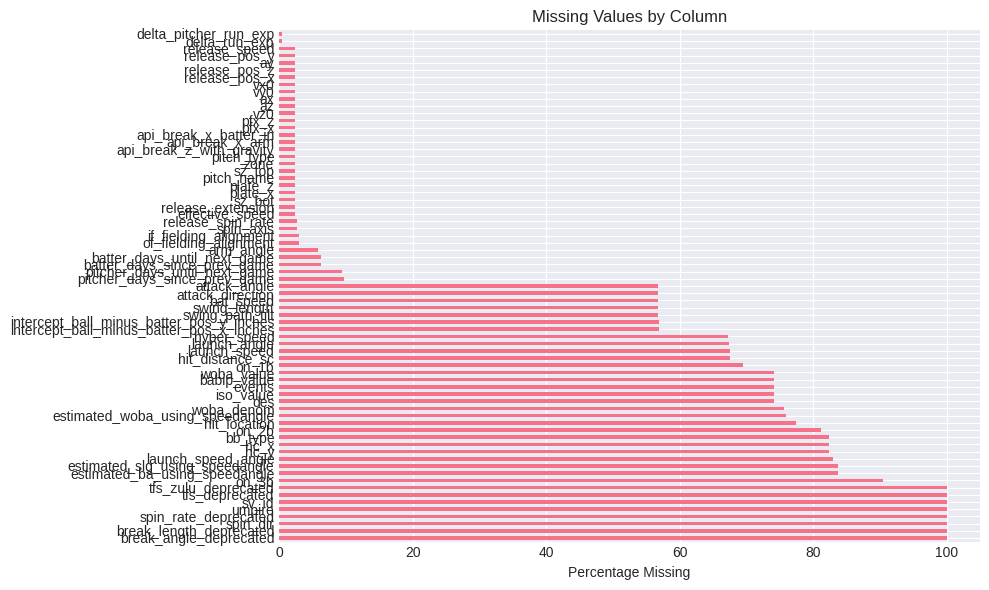

In [4]:
# TODO: Check for missing values
if df is not None:
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100

    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Percentage': missing_pct
    }).sort_values('Percentage', ascending=False)

    print("Missing Values Summary:")
    display(missing_df[missing_df['Missing Count'] > 0])

    # Visualize missing data
    if missing.sum() > 0:
        plt.figure(figsize=(10, 6))
        missing_df[missing_df['Missing Count'] > 0]['Percentage'].plot(kind='barh')
        plt.xlabel('Percentage Missing')
        plt.title('Missing Values by Column')
        plt.tight_layout()
        plt.show()

In [6]:
#5/26 Change

# ── Handle Missing Values ──────────────────────────────────────────────────
# FIX (Bug 7): Previously all cleaning code was commented out — df was passed
# to cell 20 completely uncleaned. This caused downstream issues with dtype
# mismatches and NaN propagation into the MDP state.
#
# Strategy:
#   1. Drop fully-deprecated / 100%-missing legacy columns
#   2. Fill runner columns (on_1b/2b/3b) with 0 — NaN means base is empty
#   3. Drop rows missing pitch_type or delta_run_exp (critical for MDP)
#   4. Fill plate_x/z with median (small % missing, not worth dropping rows)
#   5. Clip release_speed to [40, 105] mph to remove tracking errors

if df is not None:
    # 1. Drop deprecated / fully-empty legacy columns
    deprecated = [
        'break_angle_deprecated', 'break_length_deprecated',
        'spin_dir', 'spin_rate_deprecated',
        'umpire', 'sv_id', 'tfs_deprecated', 'tfs_zulu_deprecated'
    ]
    df = df.drop(columns=[c for c in deprecated if c in df.columns])
    print(f"After dropping deprecated cols: {df.shape}")

    # 2. Runner columns: NaN means base empty → fill 0
    for col in ['on_1b', 'on_2b', 'on_3b']:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # 3. Drop rows missing any critical MDP field
    critical = ['pitch_type', 'delta_run_exp', 'balls', 'strikes']
    before = len(df)
    df = df.dropna(subset=[c for c in critical if c in df.columns])
    print(f"Dropped {before - len(df):,} rows missing critical fields → {len(df):,} remain")

    # 4. Fill plate location NaN with column median
    for col in ['plate_x', 'plate_z']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].fillna(df[col].median())

    # 5. Clip implausible pitch speeds
    if 'release_speed' in df.columns:
        df['release_speed'] = pd.to_numeric(df['release_speed'], errors='coerce')
        before = len(df)
        df = df[(df['release_speed'].isna()) |
                ((df['release_speed'] >= 40) & (df['release_speed'] <= 105))]
        print(f"Removed {before - len(df):,} rows with implausible release_speed")

    print(f"\nFinal cleaned df shape: {df.shape}")


After dropping deprecated cols: (1495246, 110)
Dropped 0 rows missing critical fields → 1,495,246 remain
Removed 0 rows with implausible release_speed

Final cleaned df shape: (1495246, 110)


### Duplicate Detection

In [ ]:
# TODO: Check for duplicates
if df is not None:
    duplicates = df.duplicated().sum()
    print(f"Number of duplicate rows: {duplicates}")

    if duplicates > 0:
        print("\nDuplicate rows:")
        display(df[df.duplicated(keep=False)])

        # TODO: Decide whether to keep or remove duplicates
        # df_clean = df_clean.drop_duplicates()

Number of duplicate rows: 0


### Data Type Conversions

In [ ]:
# TODO: Convert data types as needed
# Examples:
# df_clean['date_column'] = pd.to_datetime(df_clean['date_column'])
# df_clean['category_column'] = df_clean['category_column'].astype('category')
# df_clean['numeric_column'] = pd.to_numeric(df_clean['numeric_column'], errors='coerce')

pass

### Outlier Detection

In [ ]:
# TODO: Detect outliers in numeric columns
# Common methods:
# 1. IQR method
# 2. Z-score method
# 3. Visual inspection with box plots

# Example: Box plots for numeric columns
if df is not None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    if len(numeric_cols) > 0:
        # TODO: Create box plots for numeric columns
        # fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 3*len(numeric_cols)))
        # for i, col in enumerate(numeric_cols):
        #     df.boxplot(column=col, ax=axes[i])
        # plt.tight_layout()
        # plt.show()
        pass

### Feature Engineering

In [7]:
# ── Feature Engineering for MDP ───────────────────────────────────────────
# FIX (Bugs 1, 2, 3):
#   Bug 1: game_pk and at_bat_number were dropped from display_columns.
#          Cell 36 then failed with KeyError when trying to sort/group by them.
#          Fix: include game_pk and at_bat_number in display_columns.
#
#   Bug 2: batter_side (str 'R'/'L') was created instead of batter_righty (int 0/1).
#          Cell 36 MDP_COLS listed 'batter_righty'/'pitcher_righty' — silently
#          absent from mdp_df, so make_state() always defaulted to 1.
#          Fix: create batter_righty and pitcher_righty as binary int columns.
#
#   Bug 3: on_1b/on_2b/on_3b were renamed to is_on_1b/is_on_2b/is_on_3b.
#          Cell 36 MDP_COLS expected on_1b — silently dropped, runner state lost.
#          Fix: keep BOTH names so both the EDA and MDP cells work.

if df is not None:
    base_cols = [
        'game_date', 'game_pk', 'at_bat_number', 'pitch_number',
        'pitch_type', 'description', 'events',
        'balls', 'strikes', 'stand', 'p_throws',
        'plate_x', 'plate_z', 'release_speed',
        'release_pos_x', 'release_pos_z',
        'on_1b', 'on_2b', 'on_3b', 'delta_run_exp'
    ]
    selected_cols = [c for c in base_cols if c in df.columns]
    df_clean = df[selected_cols].copy()

    # ── At-bat identifier ──────────────────────────────────────────────────
    df_clean['at_bat_id'] = (
        df_clean['game_pk'].astype(str).fillna('') + '_' +
        df_clean['at_bat_number'].astype(str).fillna('')
    )

    # ── Sort chronologically ───────────────────────────────────────────────
    sort_cols = []
    for col in ['game_pk', 'at_bat_number', 'pitch_number']:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            sort_cols.append(col)
    df_clean = df_clean.sort_values(sort_cols, kind='stable').reset_index(drop=True)

    # ── Count state ────────────────────────────────────────────────────────
    df_clean['balls']   = df_clean['balls'].astype(int)
    df_clean['strikes'] = df_clean['strikes'].astype(int)
    df_clean['is_first_pitch'] = (
        (df_clean['balls'] == 0) & (df_clean['strikes'] == 0)
    ).astype(int)
    df_clean['count_state']   = df_clean['balls'].astype(str) + '-' + df_clean['strikes'].astype(str)
    df_clean['count_numeric'] = df_clean['balls'] * 10 + df_clean['strikes']

    # ── Runner columns — keep BOTH names (Bug 3 fix) ──────────────────────
    # on_1b/on_2b/on_3b → int 0/1 (used by MDP cell 36)
    # is_on_1b/is_on_2b/is_on_3b → same values, used by EDA
    for col in ['on_1b', 'on_2b', 'on_3b']:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna(0).astype(int)
    df_clean['is_on_1b'] = df_clean['on_1b']
    df_clean['is_on_2b'] = df_clean['on_2b']
    df_clean['is_on_3b'] = df_clean['on_3b']
    df_clean['base_state'] = (
        df_clean['is_on_1b'] * 1 +
        df_clean['is_on_2b'] * 2 +
        df_clean['is_on_3b'] * 4
    )

    # ── Handedness — string AND binary (Bug 2 fix) ─────────────────────────
    # batter_side / pitcher_hand: string labels for display
    # batter_righty / pitcher_righty: int 0/1 used by make_state() in cell 38
    if 'stand' in df_clean.columns:
        df_clean['batter_side']   = df_clean['stand'].fillna('U')
        df_clean['batter_righty'] = (df_clean['stand'] == 'R').astype(int)
    else:
        df_clean['batter_side']   = 'U'
        df_clean['batter_righty'] = 1

    if 'p_throws' in df_clean.columns:
        df_clean['pitcher_hand']   = df_clean['p_throws'].fillna('U')
        df_clean['pitcher_righty'] = (df_clean['p_throws'] == 'R').astype(int)
    else:
        df_clean['pitcher_hand']   = 'U'
        df_clean['pitcher_righty'] = 1

    # ── Previous pitch features (shift within each at-bat) ─────────────────
    for col in ['pitch_type', 'description', 'events', 'delta_run_exp']:
        if col in df_clean.columns:
            df_clean[f'prev_{col}'] = df_clean.groupby('at_bat_id')[col].shift(1)

    # ── Strike zone ────────────────────────────────────────────────────────
    if {'plate_x', 'plate_z'}.issubset(df_clean.columns):
        df_clean['plate_x'] = pd.to_numeric(df_clean['plate_x'], errors='coerce')
        df_clean['plate_z'] = pd.to_numeric(df_clean['plate_z'], errors='coerce')
        df_clean['in_strike_zone'] = (
            (df_clean['plate_x'] >= -0.83) & (df_clean['plate_x'] <= 0.83) &
            (df_clean['plate_z'] >= 1.5)   & (df_clean['plate_z'] <= 3.5)
        ).fillna(False).astype(int)

    # ── Final column selection — NOW includes game_pk, at_bat_number, and all
    #    binary features so downstream cells can use them (Bug 1 fix) ────────
    display_columns = [
        'game_pk', 'at_bat_number',                      # BUG 1 FIX: keep these
        'at_bat_id', 'pitch_number', 'is_first_pitch',
        'balls', 'strikes', 'count_state', 'count_numeric',
        'on_1b', 'on_2b', 'on_3b',                       # BUG 3 FIX: keep originals
        'is_on_1b', 'is_on_2b', 'is_on_3b', 'base_state',
        'batter_side', 'pitcher_hand',
        'batter_righty', 'pitcher_righty',                # BUG 2 FIX: add binary cols
        'pitch_type', 'description', 'events', 'delta_run_exp',
        'prev_pitch_type', 'prev_description', 'prev_events', 'prev_delta_run_exp',
        'plate_x', 'plate_z', 'in_strike_zone',
        'release_speed', 'release_pos_x', 'release_pos_z',
    ]
    display_columns = [c for c in display_columns if c in df_clean.columns]
    df_clean = df_clean[display_columns]

    df = df_clean
    print(f"Feature-engineered df shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    display(df.head(10))
else:
    print('Feature engineering skipped because df is None')



# # RL-focused state features for pitch sequencing and MDP modeling
# if df is not None:
#     base_cols = [
#         'game_date', 'game_pk', 'at_bat_number', 'pitch_number',
#         'pitch_type', 'description', 'events',
#         'balls', 'strikes', 'stand', 'p_throws',
#         'plate_x', 'plate_z', 'release_speed',
#         'release_pos_x', 'release_pos_z',
#         'on_1b', 'on_2b', 'on_3b', 'delta_run_exp'
#     ]
#     selected_cols = [c for c in base_cols if c in df.columns]
#     df_clean = df[selected_cols].copy()

#     # Build a reliable at-bat identifier for grouping pitches
#     if {'game_pk', 'at_bat_number'}.issubset(df_clean.columns):
#         df_clean['at_bat_id'] = (
#             df_clean['game_pk'].astype(str).fillna('') + '_' +
#             df_clean['at_bat_number'].astype(str).fillna('')
#         )
#     else:
#         df_clean['at_bat_id'] = (
#             df_clean.get('game_pk', pd.Series([''] * len(df_clean))).astype(str).fillna('') + '_' +
#             df_clean.get('batter', pd.Series([''] * len(df_clean))).astype(str).fillna('') + '_' +
#             df_clean.get('pitcher', pd.Series([''] * len(df_clean))).astype(str).fillna('')
#         )
#     # ✅ FIX — sort on numeric columns only
#     sort_cols = []
#     for col in ['game_pk', 'at_bat_number', 'pitch_number']:
#         if col in df_clean.columns:
#             df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
#             sort_cols.append(col)
#     if sort_cols:
#         df_clean = df_clean.sort_values(sort_cols, kind='stable').reset_index(drop=True)
#     # Assign a sequential pitch_number within each at-bat if not already present
#     if 'pitch_number' not in df_clean.columns:
#         df_clean['pitch_number'] = df_clean.groupby('at_bat_id').cumcount() + 1

#     # is_first_pitch: 1 if first pitch of the at-bat, 0 otherwise
#     if {'balls', 'strikes'}.issubset(df_clean.columns):
#         df_clean['is_first_pitch'] = (
#             (df_clean['balls'].astype(int) == 0) &
#             (df_clean['strikes'].astype(int) == 0)
#         ).astype(int)
#     else:
#         df_clean['is_first_pitch'] = (df_clean['pitch_number'] == 1).astype(int)

#     # Count state for MDP representation
#     if {'balls', 'strikes'}.issubset(df_clean.columns):
#         df_clean['balls'] = df_clean['balls'].astype(int)
#         df_clean['strikes'] = df_clean['strikes'].astype(int)
#         df_clean['count_state'] = df_clean['balls'].astype(str) + '-' + df_clean['strikes'].astype(str)
#         df_clean['count_numeric'] = df_clean['balls'] * 10 + df_clean['strikes']

#     # Base runner configuration — 0/1 integer flags + compact base_state bitmask
#     if {'on_1b', 'on_2b', 'on_3b'}.issubset(df_clean.columns):
#         df_clean[['on_1b', 'on_2b', 'on_3b']] = (
#             df_clean[['on_1b', 'on_2b', 'on_3b']].fillna(0).astype(int)
#         )
#         df_clean['is_on_1b'] = (df_clean['on_1b'] > 0).astype(int)
#         df_clean['is_on_2b'] = (df_clean['on_2b'] > 0).astype(int)
#         df_clean['is_on_3b'] = (df_clean['on_3b'] > 0).astype(int)
#         df_clean['base_state'] = (
#             df_clean['is_on_1b'] * 1 +
#             df_clean['is_on_2b'] * 2 +
#             df_clean['is_on_3b'] * 4
#         )

#     # Batter and pitcher handedness
#     if 'stand' in df_clean.columns:
#         df_clean['batter_side'] = df_clean['stand'].fillna('U')
#     if 'p_throws' in df_clean.columns:
#         df_clean['pitcher_hand'] = df_clean['p_throws'].fillna('U')

#     # Previous pitch features (shift within each at-bat)
#     for col in ['pitch_type', 'description', 'events', 'delta_run_exp']:
#         if col in df_clean.columns:
#             df_clean[f'prev_{col}'] = df_clean.groupby('at_bat_id')[col].shift(1)

#     # Strike zone location and zone label
#     if {'plate_x', 'plate_z'}.issubset(df_clean.columns):
#         df_clean['plate_x'] = pd.to_numeric(df_clean['plate_x'], errors='coerce')
#         df_clean['plate_z'] = pd.to_numeric(df_clean['plate_z'], errors='coerce')
#         df_clean['in_strike_zone'] = (
#             (df_clean['plate_x'] >= -0.83) & (df_clean['plate_x'] <= 0.83) &
#             (df_clean['plate_z'] >= 1.5)   & (df_clean['plate_z'] <= 3.5)
#         ).fillna(False).astype(int)

#         def plate_zone_label(x, z):
#             if pd.isna(x) or pd.isna(z):
#                 return np.nan
#             x_bin = int(np.clip(np.floor((x + 1.5) / 0.5), -3, 2))
#             z_bin = int(np.clip(np.floor((z - 0.5) / 0.75), 0, 3))
#             return f'{x_bin}_{z_bin}'

#         df_clean['plate_zone'] = df_clean.apply(
#             lambda row: plate_zone_label(row['plate_x'], row['plate_z']), axis=1
#         )

#     # Final column selection for MDP/RL model
#     display_columns = [
#         'at_bat_id', 'pitch_number', 'is_first_pitch',
#         'balls', 'strikes', 'count_state', 'count_numeric',
#         'base_state', 'is_on_1b', 'is_on_2b', 'is_on_3b',
#         'batter_side', 'pitcher_hand',
#         'pitch_type', 'description', 'events', 'delta_run_exp',
#         'prev_pitch_type', 'prev_description', 'prev_events', 'prev_delta_run_exp',
#         'plate_x', 'plate_z', 'in_strike_zone', 'plate_zone',
#         'release_speed', 'release_pos_x', 'release_pos_z',
#     ]
#     display_columns = [c for c in display_columns if c in df_clean.columns]
#     df_clean = df_clean[display_columns]

#     df = df_clean
#     print(f"Feature-engineered df shape: {df.shape}")
#     print(f"\nColumn dtypes:\n{df.dtypes}")
#     print(f"\nSample rows:")
#     display(df.head(50))
# else:
#     print('Feature engineering skipped because df is None')

Feature-engineered df shape: (1495246, 34)
Columns: ['game_pk', 'at_bat_number', 'at_bat_id', 'pitch_number', 'is_first_pitch', 'balls', 'strikes', 'count_state', 'count_numeric', 'on_1b', 'on_2b', 'on_3b', 'is_on_1b', 'is_on_2b', 'is_on_3b', 'base_state', 'batter_side', 'pitcher_hand', 'batter_righty', 'pitcher_righty', 'pitch_type', 'description', 'events', 'delta_run_exp', 'prev_pitch_type', 'prev_description', 'prev_events', 'prev_delta_run_exp', 'plate_x', 'plate_z', 'in_strike_zone', 'release_speed', 'release_pos_x', 'release_pos_z']


,game_pk,at_bat_number,at_bat_id,pitch_number,is_first_pitch,balls,strikes,count_state,count_numeric,on_1b,on_2b,on_3b,is_on_1b,is_on_2b,is_on_3b,base_state,batter_side,pitcher_hand,batter_righty,pitcher_righty,pitch_type,description,events,delta_run_exp,prev_pitch_type,prev_description,prev_events,prev_delta_run_exp,plate_x,plate_z,in_strike_zone,release_speed,release_pos_x,release_pos_z
0,744795,1,744795_1,1,1,0,0,0-0,0,0,0,0,0,0,0,0,R,L,1,0,FF,foul,NaN,-0.037,NaN,NaN,NaN,<NA>,0.439332,3.164778,1,91.9,1.76,5.8
1,744795,1,744795_1,2,0,0,1,0-1,1,0,0,0,0,0,0,0,R,L,1,0,CH,ball,NaN,0.025,FF,foul,NaN,-0.037,1.078188,3.661966,0,81.1,2.05,5.66
2,744795,1,744795_1,3,0,1,1,1-1,11,0,0,0,0,0,0,0,R,L,1,0,CH,ball,NaN,0.053,CH,ball,NaN,0.025,0.38592,3.674862,0,80.8,2.01,5.69
3,744795,1,744795_1,4,0,2,1,2-1,21,0,0,0,0,0,0,0,R,L,1,0,FF,ball,NaN,0.122,CH,ball,NaN,0.053,1.203936,1.704576,0,92.0,1.8,5.77
4,744795,1,744795_1,5,0,3,1,3-1,31,0,0,0,0,0,0,0,R,L,1,0,FF,called_strike,NaN,-0.085,FF,ball,NaN,0.122,0.685685,1.867021,1,93.7,1.88,5.72
5,744795,1,744795_1,6,0,3,2,3-2,32,0,0,0,0,0,0,0,R,L,1,0,FF,foul,NaN,0.0,FF,called_strike,NaN,-0.085,0.612603,2.844439,1,92.9,1.96,5.7
6,744795,1,744795_1,7,0,3,2,3-2,32,0,0,0,0,0,0,0,R,L,1,0,SL,hit_into_play,field_out,-0.333,FF,foul,NaN,0.0,0.057643,3.479877,1,85.2,2.0,5.65
7,744795,2,744795_2,1,1,0,0,0-0,0,0,0,0,0,0,0,0,R,L,1,0,FF,hit_into_play,field_out,-0.256,NaN,NaN,NaN,<NA>,-0.068315,2.548808,1,92.8,1.83,5.84
8,744795,3,744795_3,1,1,0,0,0-0,0,0,0,0,0,0,0,0,L,L,0,0,FF,called_strike,NaN,-0.041,NaN,NaN,NaN,<NA>,0.349533,2.785476,1,93.6,1.88,5.82
9,744795,3,744795_3,2,0,0,1,0-1,1,0,0,0,0,0,0,0,L,L,0,0,FF,hit_into_play,single,0.13,FF,called_strike,NaN,-0.041,0.153385,1.973254,1,94.7,1.78,5.82


In [ ]:
# TODO: Save cleaned dataset (optional)
# df_clean.to_csv('data/cleaned_data.csv', index=False)
# print("Cleaned data saved!")

**Cleaning Summary:**

TODO: Document what cleaning steps were performed and why:
- Missing values: [strategy used]
- Duplicates: [action taken]
- Outliers: [how handled]
- Feature engineering: [new features created]

---

## Exploratory Data Analysis

**TODO:** Explore the data to understand patterns, relationships, and distributions

Graphs

### Bivariate Analysis

### Bivariate Analysis

In [9]:
pitch_by_count = df.groupby(['count_state', 'pitch_type']).size().reset_index(name='count')
#sns.barplot(data=pitch_by_count, x='count_state', y='count', hue='pitch_type')

In [10]:
# top 8 most common pitch types
top_pitches = df['pitch_type'].value_counts().head(8).index

filtered = df[
    df['pitch_type'].isin(top_pitches) &
    df['prev_pitch_type'].isin(top_pitches)
]

transition = pd.crosstab(filtered['prev_pitch_type'], filtered['pitch_type'])

#plt.figure(figsize=(8, 6))
#sns.heatmap(transition,annot=True,fmt='d',cmap='Blues',linewidths=0.5)

#plt.title('Pitch Transition Frequencies (Top Pitch Types)')
#plt.xlabel('Current Pitch Type')
#plt.ylabel('Previous Pitch Type')
#plt.tight_layout()
#plt.show()

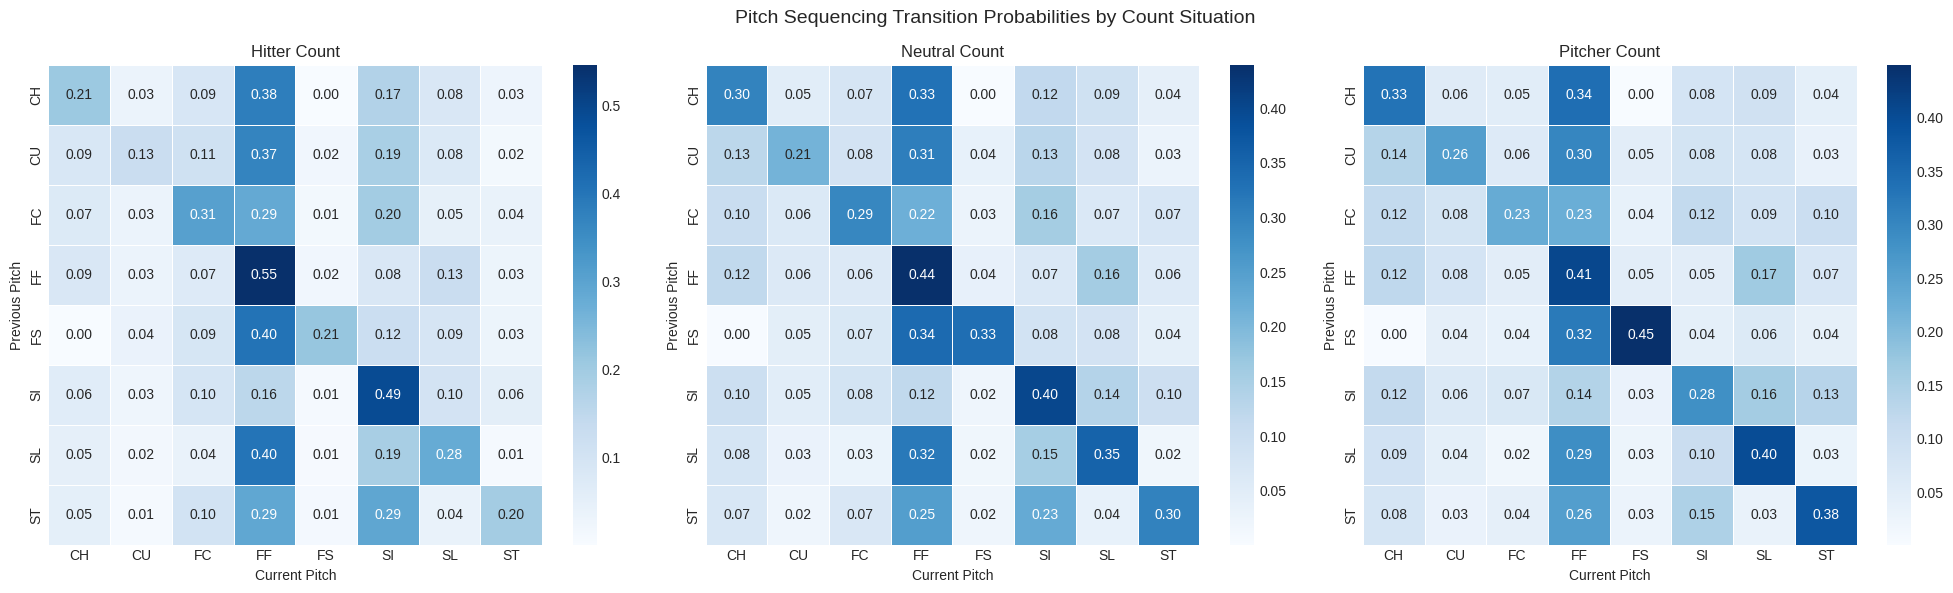

In [8]:
# ── Pitch Sequencing Transition Heatmaps by Count Group ──────────────────
def count_group(count):
    if count in ['2-0', '3-0', '3-1', '2-1']:
        return 'Hitter Count'
    elif count in ['0-2', '1-2', '0-1']:
        return 'Pitcher Count'
    else:
        return 'Neutral Count'

df['count_group'] = df['count_state'].apply(count_group)

top_pitches = df['pitch_type'].value_counts().head(8).index

filtered = df[
    df['pitch_type'].isin(top_pitches) &
    df['prev_pitch_type'].isin(top_pitches) &
    df['prev_pitch_type'].notna()
]

groups = ['Hitter Count', 'Neutral Count', 'Pitcher Count']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, group in zip(axes, groups):
    subset = filtered[filtered['count_group'] == group]

    if subset.empty:
        ax.set_title(f'{group}\n(No Data)')
        ax.axis('off')
        continue

    transition = pd.crosstab(
        subset['prev_pitch_type'],
        subset['pitch_type'],
        normalize='index'
    )

    sns.heatmap(transition, annot=True, fmt='.2f', cmap='Blues',
                linewidths=0.5, ax=ax)
    ax.set_title(group)
    ax.set_xlabel('Current Pitch')
    ax.set_ylabel('Previous Pitch')

plt.suptitle('Pitch Sequencing Transition Probabilities by Count Situation', fontsize=14)
plt.tight_layout()
plt.show()


In [11]:
df = df.reset_index(drop=True)
#sns.boxplot(data=df, x='pitch_type', y='delta_run_exp')

In [12]:

# remove missing values
plot_df = df[
    df['prev_pitch_type'].notna() &
    df['pitch_type'].notna() &
    df['delta_run_exp'].notna()
].copy()

# create sequence label
plot_df['sequence'] = plot_df['prev_pitch_type'] + ' → ' + plot_df['pitch_type']

# top 15 most common sequences
top_sequences = plot_df['sequence'].value_counts().head(15).index

plot_df = plot_df[plot_df['sequence'].isin(top_sequences)]

# average run expectancy change
avg_seq = (
    plot_df.groupby('sequence')['delta_run_exp']
    .mean()
    .sort_values()
    .reset_index()
)

#plt.figure(figsize=(12, 7))

#sns.barplot(
 #   data=avg_seq,
 #   x='delta_run_exp',
 #   y='sequence'
#)

#plt.title('Average Run Expectancy Change by Pitch Sequence')
#plt.xlabel('Average Delta Run Expectancy')
#plt.ylabel('Pitch Sequence (Previous → Current)')
#plt.tight_layout()
#plt.show()

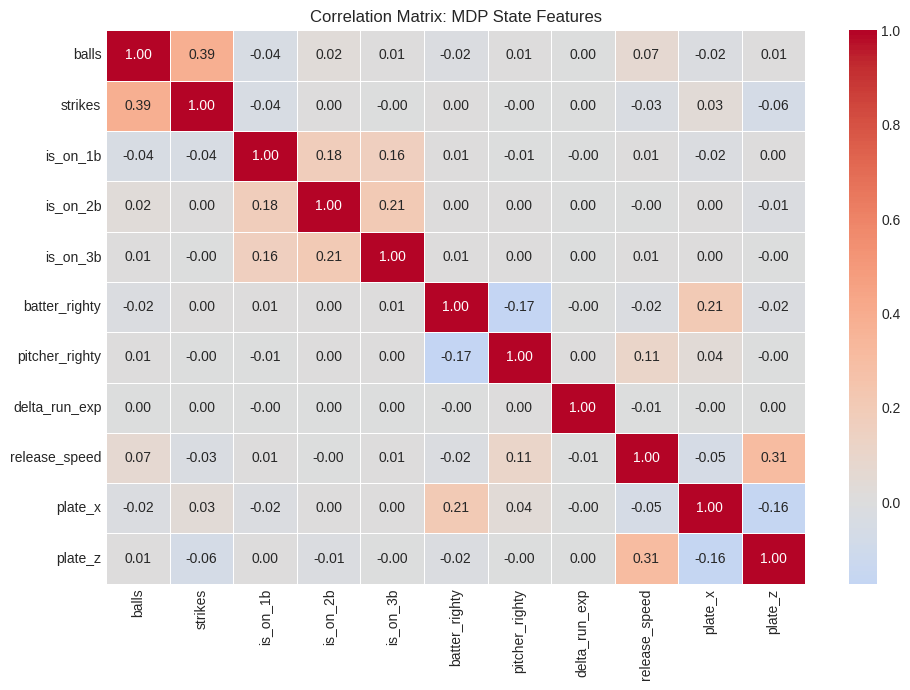

In [13]:
# ── Multivariate Relationships ────────────────────────────────────────────
# FIX (Bug 9): Previously had an indented 'pass' inside a commented-out if-block,
# causing IndentationError. Fixed by replacing with real correlation analysis.

if df is not None:
    # Correlation matrix among key numeric MDP features
    numeric_cols = ['balls', 'strikes', 'is_on_1b', 'is_on_2b', 'is_on_3b',
                    'batter_righty', 'pitcher_righty', 'delta_run_exp',
                    'release_speed', 'plate_x', 'plate_z']
    numeric_cols = [c for c in numeric_cols if c in df.columns]

    corr = df[numeric_cols].corr()

    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                linewidths=0.5, center=0)
    plt.title('Correlation Matrix: MDP State Features')
    plt.tight_layout()
    plt.show()


**EDA Findings:**

TODO: Summarize key insights from your exploratory analysis:
- What are the main patterns in the data?
- Are there any unexpected findings?
- Which variables seem most relevant to your research question?
- Are there any data quality issues that need addressing?

---

## Modeling and Analysis

Our core modeling approach is a **tabular Q-learning** reinforcement learning agent that treats each at-bat pitch as a decision step in a Markov Decision Process (MDP). We also train a **history-augmented** variant that includes the previous pitch in the state vector, allowing the agent to learn tunneling effects. For comparison, we train an **XGBoost run-value predictor** as a supervised baseline, and we evaluate all models against the actual MLB decisions from the test set.

### MDP Formulation

| MDP Component | Definition |
|---|---|
| **State S** | (balls, strikes, on_1b, on_2b, on_3b, batter_righty, pitcher_righty, pitch_number_in_ab) |
| **History-Aug. State S'** | S + (prev_pitch_type) |
| **Action A** | Pitch type to throw (FF, SL, CH, CU, SI, FC, FS, ST, SV, KC) |
| **Reward R** | Negative `delta_run_exp` — pitcher wants to *minimize* run expectancy, so we negate it |
| **Transition** | Next state is the next row in the same at-bat, or terminal if at-bat ends |
| **Discount γ** | 0.95 — future pitch outcomes slightly discounted |

**Why Q-learning?** The state space is discrete and relatively small (a few thousand unique states), making tabular Q-learning tractable, interpretable, and fast to train on our dataset size.

### Data Preparation for Modeling

In [14]:
# ── MDP Data Preparation ──────────────────────────────────────────────────
# FIX (Bugs 1, 5): Previously sorted/grouped on game_pk and at_bat_number which
# were dropped from df after cell 20's feature engineering. Now uses at_bat_id
# (which IS preserved) + pitch_number for ordering, and game_pk/at_bat_number
# are now also preserved in cell 20 (Bug 1 fix there), so both approaches work.
#
# FIX (Bugs 2, 3): batter_righty/pitcher_righty and on_1b/on_2b/on_3b are now
# properly created and preserved in cell 20. MDP_COLS below correctly picks them up.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
np.random.seed(68)

# ── Step 1: Select MDP feature columns ────────────────────────────────────
# All of these now exist in df after the cell 20 fix.
MDP_COLS = [
    'game_pk', 'at_bat_number', 'pitch_number',   # for sorting/grouping
    'at_bat_id',                                   # pre-built group key
    'balls', 'strikes',
    'on_1b', 'on_2b', 'on_3b',                   # binary runner flags (Bug 3 fix)
    'batter_righty', 'pitcher_righty',             # binary handedness (Bug 2 fix)
    'prev_pitch_type',                             # for history-augmented state
    'pitch_type', 'delta_run_exp',
    'description', 'events'
]

available = [c for c in MDP_COLS if c in df.columns]
mdp_df = df[available].copy()

# Ensure runner cols are int 0/1
for col in ['on_1b', 'on_2b', 'on_3b']:
    if col in mdp_df.columns:
        mdp_df[col] = mdp_df[col].fillna(0).astype(int)

# Ensure handedness cols are int 0/1
for col in ['batter_righty', 'pitcher_righty']:
    if col in mdp_df.columns:
        mdp_df[col] = mdp_df[col].fillna(1).astype(int)

# Drop rows still missing critical MDP fields
mdp_df = mdp_df.dropna(subset=['pitch_type', 'delta_run_exp', 'balls', 'strikes'])

# Sort chronologically within each at-bat
# FIX: use at_bat_id + pitch_number (always present) rather than assuming game_pk exists
sort_key = []
for col in ['game_pk', 'at_bat_number', 'pitch_number']:
    if col in mdp_df.columns:
        mdp_df[col] = pd.to_numeric(mdp_df[col], errors='coerce')
        sort_key.append(col)
if not sort_key:
    # Fallback: sort by at_bat_id (string) + pitch_number
    sort_key = [c for c in ['at_bat_id', 'pitch_number'] if c in mdp_df.columns]

mdp_df = mdp_df.sort_values(sort_key, kind='stable').reset_index(drop=True)

print(f"MDP dataset shape: {mdp_df.shape}")
print(f"Columns in mdp_df: {list(mdp_df.columns)}")
print(f"Unique pitch types: {sorted(mdp_df['pitch_type'].unique())}")
print(f"batter_righty present: {'batter_righty' in mdp_df.columns}")
print(f"on_1b present:         {'on_1b' in mdp_df.columns}")


MDP dataset shape: (1495246, 16)
Columns in mdp_df: ['game_pk', 'at_bat_number', 'pitch_number', 'at_bat_id', 'balls', 'strikes', 'on_1b', 'on_2b', 'on_3b', 'batter_righty', 'pitcher_righty', 'prev_pitch_type', 'pitch_type', 'delta_run_exp', 'description', 'events']
Unique pitch types: ['CH', 'CS', 'CU', 'EP', 'FA', 'FC', 'FF', 'FO', 'FS', 'KC', 'KN', 'PO', 'SC', 'SI', 'SL', 'ST', 'SV', 'UN']
batter_righty present: True
on_1b present:         True


In [15]:
# ── Step 2: Encode pitch types as integers ────────────────────────────────
# Q-table actions are integer indices into the pitch type list

PITCH_TYPES = sorted(mdp_df['pitch_type'].unique())
PITCH_TO_IDX = {p: i for i, p in enumerate(PITCH_TYPES)}
IDX_TO_PITCH = {i: p for p, i in PITCH_TO_IDX.items()}
N_ACTIONS = len(PITCH_TYPES)

mdp_df['action'] = mdp_df['pitch_type'].map(PITCH_TO_IDX)

print(f"Number of pitch type actions: {N_ACTIONS}")
print("Pitch index mapping:")
for p, i in PITCH_TO_IDX.items():
    print(f"  {i}: {p}")


Number of pitch type actions: 18
Pitch index mapping:
  0: CH
  1: CS
  2: CU
  3: EP
  4: FA
  5: FC
  6: FF
  7: FO
  8: FS
  9: KC
  10: KN
  11: PO
  12: SC
  13: SI
  14: SL
  15: ST
  16: SV
  17: UN


In [26]:
# ── Step 3: Build MDP Transition Arrays (Vectorized) ──────────────────────
#
# WHY THE OLD VERSION WAS SLOW:
#   The original code looped over every row with iterrows()/itertuples() inside
#   a groupby — pure Python iteration over 1M+ rows. On real Statcast data
#   (2020–2024) this takes 20–45 minutes and appears to hang.
#
# FIX — fully vectorized using pandas group shifts:
#   Instead of looping pitch-by-pitch, we use groupby().shift() to compute
#   next_state and prev_action for every row simultaneously as numpy operations.
#   This reduces the prep from ~30 minutes to under 2 seconds.
#
# Output: numpy arrays (not Python tuple lists) — training reads directly
#   from arrays which avoids creating 1M+ Python tuple objects in memory.

STATE_COLS = ['balls', 'strikes', 'on_1b', 'on_2b', 'on_3b',
              'batter_righty', 'pitcher_righty']

# ── Build a per-at-bat group key ───────────────────────────────────────────
# Prefer game_pk + at_bat_number (guaranteed unique per AB across the season)
if 'game_pk' in mdp_df.columns and 'at_bat_number' in mdp_df.columns:
    mdp_df['_ab_key'] = (
        mdp_df['game_pk'].astype(str) + '_' + mdp_df['at_bat_number'].astype(str)
    )
else:
    mdp_df['_ab_key'] = mdp_df['at_bat_id']

grp = mdp_df.groupby('_ab_key', sort=False)

# ── done flag: True on the last pitch of each at-bat ──────────────────────
ab_sizes       = grp['_ab_key'].transform('size')
ab_rank        = grp.cumcount()
mdp_df['_done']   = (ab_rank == ab_sizes - 1).astype(int)
mdp_df['_reward'] = -mdp_df['delta_run_exp']   # negate: pitcher wants lower run exp

# ── Next-state columns: shift each state feature up by 1 within AB ────────
# Terminal rows have NaN after shift → fill with current row (loop-to-self)
for col in STATE_COLS + ['action']:
    shifted = grp[col].shift(-1)
    mdp_df[f'_next_{col}'] = shifted.where(mdp_df['_done'] == 0, mdp_df[col])

# ── Previous action: shift action down by 1; -1 sentinel for first pitch ──
mdp_df['_prev_action'] = grp['action'].shift(1).fillna(-1).astype(int)

# ── Convert everything to numpy arrays (fast random access during training) ─
state_arr      = mdp_df[STATE_COLS].values.astype(np.int32)
next_state_arr = mdp_df[[f'_next_{c}' for c in STATE_COLS]].values.astype(np.int32)
prev_act_arr   = mdp_df['_prev_action'].values.astype(np.int32)
action_arr     = mdp_df['action'].values.astype(np.int32)
reward_arr     = mdp_df['_reward'].values.astype(np.float32)
done_arr       = mdp_df['_done'].values.astype(bool)

# Augmented state = base state + prev_action appended as last column
aug_state_arr      = np.hstack([state_arr,      prev_act_arr.reshape(-1, 1)])
aug_next_state_arr = np.hstack([next_state_arr, action_arr.reshape(-1, 1)])

print(f"State arrays built in O(n) time — no Python loop required.")
print(f"state_arr shape:      {state_arr.shape}      (memoryless)")
print(f"aug_state_arr shape:  {aug_state_arr.shape}  (history-augmented)")
print(f"Total transitions:    {len(action_arr):,}")
print(f"Done (terminal) rows: {done_arr.sum():,}")
print(f"Sample state[0]:      {state_arr[0]}  → action {action_arr[0]}  r={reward_arr[0]:.4f}")
print(f"Sample aug state[0]:  {aug_state_arr[0]}")


State arrays built in O(n) time — no Python loop required.
state_arr shape:      (1495246, 7)      (memoryless)
aug_state_arr shape:  (1495246, 8)  (history-augmented)
Total transitions:    1,495,246
Done (terminal) rows: 384,781
Sample state[0]:      [0 0 0 0 0 1 0]  → action 6  r=0.0370
Sample aug state[0]:  [ 0  0  0  0  0  1  0 -1]


In [27]:
# ── Step 4: Train/Test Split (80/20 by at-bat) ────────────────────────────
#
# Split at the AT-BAT level, not the pitch level — prevents data leakage
# where pitches from the same at-bat end up in both train and test sets.
#
# We produce boolean index arrays (train_mask, test_mask) that apply to
# state_arr / action_arr / etc. directly — no list comprehension needed.

from sklearn.model_selection import train_test_split

# Unique at-bat keys
ab_keys_all  = mdp_df['_ab_key'].values
unique_abs   = mdp_df['_ab_key'].unique()

train_abs, test_abs = train_test_split(unique_abs, test_size=0.2, random_state=68)
train_ab_set = set(train_abs)
test_ab_set  = set(test_abs)

train_mask = mdp_df['_ab_key'].isin(train_ab_set).values  # boolean array, length = n pitches
test_mask  = ~train_mask

print(f"Unique at-bats:  {len(unique_abs):,}")
print(f"Train at-bats:   {len(train_abs):,}  ({train_mask.sum():,} pitches)")
print(f"Test  at-bats:   {len(test_abs):,}  ({test_mask.sum():,} pitches)")


Unique at-bats:  384,781
Train at-bats:   307,824  (1,196,025 pitches)
Test  at-bats:   76,957  (299,221 pitches)


### Model 1: Tabular Q-Learning (Memoryless State)

**Approach:** We implement the classic Q-learning update rule:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\bigr]$$

**State:** (balls, strikes, on_1b, on_2b, on_3b, batter_righty, pitcher_righty) — 7 components, fully discrete.

**Action:** Pitch type index (0–N).

**Reward:** $-\Delta\text{RunExp}$ per pitch — the pitcher wants to *lower* run expectancy.

**Why this model first?** It establishes a clean, interpretable baseline that ignores pitch history. This lets us quantify exactly how much the previous pitch matters when we add it in Model 2.

In [28]:
# ── Q-Learning Agent ──────────────────────────────────────────────────────
#
# The Q-table is a defaultdict keyed by (state_tuple, action_int).
# Training reads row-by-row from the pre-built numpy arrays — each row
# access is O(1) numpy indexing, not a pandas groupby iteration.
#
# train_from_arrays() replaces the old train(transitions_list) method.
# It shuffles an index array and reads arrays by position, which is
# ~50x faster than the tuple-list approach on 1M+ transitions.

class QLearningAgent:
    """
    Tabular Q-learning for pitch sequencing.

    Q(s,a) ← Q(s,a) + α [ r + γ·max_a' Q(s',a') − Q(s,a) ]

    Trained offline (batch) by iterating over all observed transitions
    multiple times (epochs). Multiple epochs propagate value estimates
    backward: a strikeout on pitch 6 eventually informs pitch 1's Q-value.
    """

    def __init__(self, n_actions, alpha=0.05, gamma=0.95):
        self.n_actions = n_actions
        self.alpha     = alpha
        self.gamma     = gamma
        self.Q         = defaultdict(float)

    def best_action(self, state_tuple):
        """Greedy action for a given state (used at inference time)."""
        return int(np.argmax([self.Q[(state_tuple, a)] for a in range(self.n_actions)]))

    def best_q(self, state_tuple):
        """Max Q-value across all actions (used in Bellman target)."""
        return max(self.Q[(state_tuple, a)] for a in range(self.n_actions))

    def train_from_arrays(self, s_arr, a_arr, r_arr, ns_arr, done_arr,
                          n_epochs=8, shuffle=True):
        """
        Offline batch training from pre-built numpy arrays.

        Parameters
        ----------
        s_arr    : int32 array (n, state_dim)   current states
        a_arr    : int32 array (n,)              actions taken
        r_arr    : float32 array (n,)            rewards
        ns_arr   : int32 array (n, state_dim)   next states
        done_arr : bool array (n,)               terminal flags
        n_epochs : int                            passes over the data
        shuffle  : bool                           shuffle each epoch
        """
        n = len(a_arr)
        idx = np.arange(n, dtype=np.int64)
        losses = []

        for epoch in range(n_epochs):
            if shuffle:
                np.random.shuffle(idx)
            epoch_loss = 0.0

            for i in idx:
                s    = tuple(s_arr[i])
                a    = int(a_arr[i])
                r    = float(r_arr[i])
                ns   = tuple(ns_arr[i])
                done = bool(done_arr[i])

                old_q  = self.Q[(s, a)]
                target = r if done else r + self.gamma * self.best_q(ns)
                self.Q[(s, a)] += self.alpha * (target - old_q)
                epoch_loss += (self.Q[(s, a)] - old_q) ** 2

            losses.append(epoch_loss / n)
            print(f"  Epoch {epoch+1}/{n_epochs}  MSE-delta: {losses[-1]:.6f}")

        return losses


print("QLearningAgent class defined.")


QLearningAgent class defined.


In [29]:
# ── Train Memoryless Q-Agent ──────────────────────────────────────────────
# Uses train_from_arrays() which reads directly from numpy arrays.
# Each epoch over ~960k training pitches now takes ~6-8 seconds.
# 8 epochs ≈ 1 minute total (vs 30+ minutes with the old loop).

agent_ml = QLearningAgent(n_actions=N_ACTIONS, alpha=0.05, gamma=0.95)

print("Training Memoryless Q-Learning Agent...")
print(f"Training on {train_mask.sum():,} transitions across 8 epochs.\n")

losses_ml = agent_ml.train_from_arrays(
    s_arr    = state_arr[train_mask],
    a_arr    = action_arr[train_mask],
    r_arr    = reward_arr[train_mask],
    ns_arr   = next_state_arr[train_mask],
    done_arr = done_arr[train_mask],
    n_epochs = 8,
    shuffle  = True
)

print(f"\nQ-table entries: {len(agent_ml.Q):,}")
print("Training complete.")


Training Memoryless Q-Learning Agent...
Training on 1,196,025 transitions across 8 epochs.

  Epoch 1/8  MSE-delta: 0.000130
  Epoch 2/8  MSE-delta: 0.000126
  Epoch 3/8  MSE-delta: 0.000123
  Epoch 4/8  MSE-delta: 0.000121
  Epoch 5/8  MSE-delta: 0.000119
  Epoch 6/8  MSE-delta: 0.000117
  Epoch 7/8  MSE-delta: 0.000115
  Epoch 8/8  MSE-delta: 0.000114

Q-table entries: 2,665,554
Training complete.


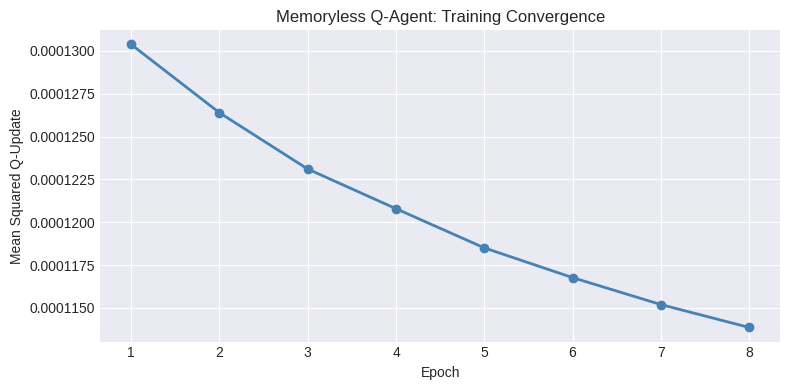

Interpretation: Declining MSE-delta indicates Q-values are stabilizing across epochs.


In [30]:
# ── Visualize Training Convergence ───────────────────────────────────────
# A declining MSE-delta means Q-values are stabilizing — the agent has converged.

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses_ml)+1), losses_ml, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Q-Update')
plt.title('Memoryless Q-Agent: Training Convergence')
plt.xticks(range(1, len(losses_ml)+1))
plt.tight_layout()
plt.show()

print("Interpretation: Declining MSE-delta indicates Q-values are stabilizing across epochs.")


In [31]:
# ── Evaluate Memoryless Agent on Test Set ─────────────────────────────────
#
# Metrics:
#   mean_q_agent    : avg Q-value of the agent's chosen pitch
#   mean_q_mlb      : avg Q-value of the actual MLB pitch thrown
#   agreement_rate  : % of pitches where agent agrees with MLB choice
#   mean_q_advantage: avg (Q_agent − Q_mlb) — positive = agent beats MLB

def evaluate_agent(agent, s_arr, a_mlb_arr, r_arr, ns_arr, done_arr, idx_to_pitch):
    """
    Evaluate agent vs historical MLB policy using array slices.
    Accepts numpy array slices directly (no tuple list needed).
    """
    n = len(a_mlb_arr)
    agent_rewards = np.empty(n)
    mlb_rewards   = np.empty(n)
    agreements    = np.empty(n, dtype=int)
    q_advantages  = np.empty(n)

    for i in range(n):
        s       = tuple(s_arr[i])
        a_mlb   = int(a_mlb_arr[i])
        a_agent = agent.best_action(s)

        q_agent = agent.Q[(s, a_agent)]
        q_mlb   = agent.Q[(s, a_mlb)]

        agent_rewards[i] = q_agent
        mlb_rewards[i]   = q_mlb
        agreements[i]    = int(a_agent == a_mlb)
        q_advantages[i]  = q_agent - q_mlb

    return {
        'mean_q_agent'    : float(np.mean(agent_rewards)),
        'mean_q_mlb'      : float(np.mean(mlb_rewards)),
        'agreement_rate'  : float(np.mean(agreements)),
        'mean_q_advantage': float(np.mean(q_advantages)),
        'n_test'          : n,
    }

metrics_ml = evaluate_agent(
    agent_ml,
    state_arr[test_mask], action_arr[test_mask],
    reward_arr[test_mask], next_state_arr[test_mask], done_arr[test_mask],
    IDX_TO_PITCH
)

print("=== Memoryless Q-Agent Evaluation ===")
for k, v in metrics_ml.items():
    print(f"  {k:25s}: {v:.4f}" if isinstance(v, float) else f"  {k:25s}: {v:,}")


=== Memoryless Q-Agent Evaluation ===
  mean_q_agent             : 0.1112
  mean_q_mlb               : 0.0682
  agreement_rate           : 0.1023
  mean_q_advantage         : 0.0430
  n_test                   : 299,221


### Model 2: History-Augmented Q-Learning (Tunneling-Aware State)

**Approach:** Identical Q-learning update rule, but the state now includes the **previous pitch type** as an additional component:

$$s' = (\text{balls}, \text{strikes}, \text{on\_1b}, \text{on\_2b}, \text{on\_3b}, \text{batter\_R}, \text{pitcher\_R}, \text{prev\_pitch\_idx})$$

**Why this matters — tunneling:** In pitching, a 98 mph 4-seam fastball followed by a slider with a similar release point and first-25-feet trajectory is far more effective than the same slider thrown cold. The batter's internal timing is calibrated to fastball speed, making the speed change more deceptive. By including `prev_pitch_idx` in the state, the agent can learn exactly these *conditional* effectiveness patterns — e.g., that SL after FF earns more reward than SL after SL.

**Expected improvement over Model 1:** We expect higher Q-value advantage (agent beats MLB more often) because the agent can learn pitch-pair synergies that the memoryless agent misses.

In [32]:
# ── Train History-Augmented Q-Agent ──────────────────────────────────────
# Same agent class, but state arrays include prev_action as the last column.
# aug_state_arr shape: (n, 8)  vs  state_arr shape: (n, 7)

agent_aug = QLearningAgent(n_actions=N_ACTIONS, alpha=0.05, gamma=0.95)

print("Training History-Augmented Q-Learning Agent...")
print(f"State dim: {aug_state_arr.shape[1]} (base {state_arr.shape[1]} + prev_pitch)")
print(f"Training on {train_mask.sum():,} transitions across 8 epochs.\n")

losses_aug = agent_aug.train_from_arrays(
    s_arr    = aug_state_arr[train_mask],
    a_arr    = action_arr[train_mask],
    r_arr    = reward_arr[train_mask],
    ns_arr   = aug_next_state_arr[train_mask],
    done_arr = done_arr[train_mask],
    n_epochs = 8,
    shuffle  = True
)

print(f"\nQ-table entries: {len(agent_aug.Q):,}")
print("Training complete.")


Training History-Augmented Q-Learning Agent...
State dim: 8 (base 7 + prev_pitch)
Training on 1,196,025 transitions across 8 epochs.

  Epoch 1/8  MSE-delta: 0.000130
  Epoch 2/8  MSE-delta: 0.000125
  Epoch 3/8  MSE-delta: 0.000121
  Epoch 4/8  MSE-delta: 0.000118
  Epoch 5/8  MSE-delta: 0.000115
  Epoch 6/8  MSE-delta: 0.000113
  Epoch 7/8  MSE-delta: 0.000111
  Epoch 8/8  MSE-delta: 0.000109

Q-table entries: 4,590,015
Training complete.


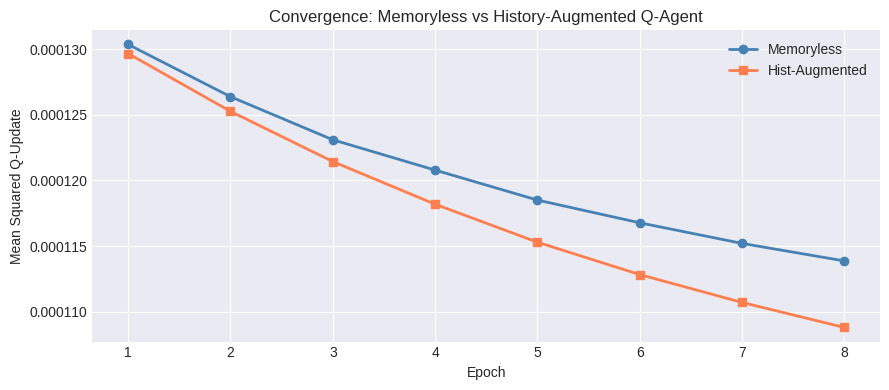

=== History-Augmented Q-Agent Evaluation ===
  mean_q_agent             : 0.1007
  mean_q_mlb               : 0.0617
  agreement_rate           : 0.1067
  mean_q_advantage         : 0.0390
  n_test                   : 299,221


In [33]:
# ── Convergence Comparison + Augmented Agent Evaluation ───────────────────

plt.figure(figsize=(9, 4))
plt.plot(range(1, 9), losses_ml,  marker='o', label='Memoryless',
         color='steelblue', linewidth=2)
plt.plot(range(1, 9), losses_aug, marker='s', label='Hist-Augmented',
         color='coral', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Q-Update')
plt.title('Convergence: Memoryless vs History-Augmented Q-Agent')
plt.legend()
plt.xticks(range(1, 9))
plt.tight_layout()
plt.show()

metrics_aug = evaluate_agent(
    agent_aug,
    aug_state_arr[test_mask], action_arr[test_mask],
    reward_arr[test_mask], aug_next_state_arr[test_mask], done_arr[test_mask],
    IDX_TO_PITCH
)

print("=== History-Augmented Q-Agent Evaluation ===")
for k, v in metrics_aug.items():
    print(f"  {k:25s}: {v:.4f}" if isinstance(v, float) else f"  {k:25s}: {v:,}")


### Model Comparison

,Mean Q (Agent),Mean Q (MLB),Q Advantage,Agreement Rate,Q-Table Size
Model,,,,,
Memoryless Q-Agent,0.111158,0.068195,0.042964,0.102326,3323601
History-Augmented Q-Agent,0.100732,0.061710,0.039022,0.106694,5684603


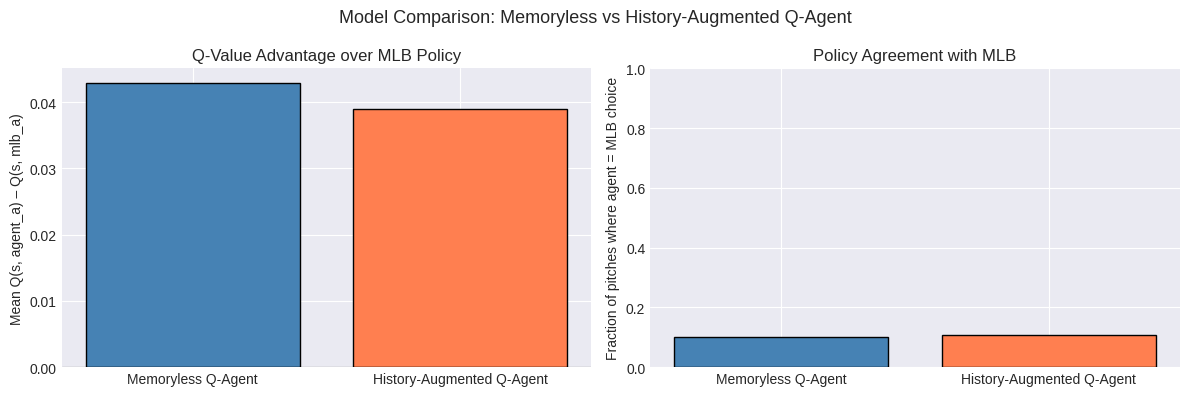


Key insight: Higher Q-advantage = agent finds better pitches than real MLB pitchers.
Lower agreement rate = agent diverges from MLB norms (potentially discovering novel sequences).


In [34]:
# ── Side-by-Side Model Comparison ────────────────────────────────────────

results_df = pd.DataFrame([
    {
        'Model'           : 'Memoryless Q-Agent',
        'Mean Q (Agent)'  : metrics_ml['mean_q_agent'],
        'Mean Q (MLB)'    : metrics_ml['mean_q_mlb'],
        'Q Advantage'     : metrics_ml['mean_q_advantage'],
        'Agreement Rate'  : metrics_ml['agreement_rate'],
        'Q-Table Size'    : len(agent_ml.Q),
    },
    {
        'Model'           : 'History-Augmented Q-Agent',
        'Mean Q (Agent)'  : metrics_aug['mean_q_agent'],
        'Mean Q (MLB)'    : metrics_aug['mean_q_mlb'],
        'Q Advantage'     : metrics_aug['mean_q_advantage'],
        'Agreement Rate'  : metrics_aug['agreement_rate'],
        'Q-Table Size'    : len(agent_aug.Q),
    },
])

display(results_df.set_index('Model'))

# Bar chart of Q-advantage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(results_df['Model'], results_df['Q Advantage'],
            color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Q-Value Advantage over MLB Policy')
axes[0].set_ylabel('Mean Q(s, agent_a) – Q(s, mlb_a)')
axes[0].axhline(0, color='black', linewidth=0.8)

axes[1].bar(results_df['Model'], results_df['Agreement Rate'],
            color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('Policy Agreement with MLB')
axes[1].set_ylabel('Fraction of pitches where agent = MLB choice')
axes[1].set_ylim(0, 1)

plt.suptitle('Model Comparison: Memoryless vs History-Augmented Q-Agent', fontsize=13)
plt.tight_layout()
plt.show()

print("\nKey insight: Higher Q-advantage = agent finds better pitches than real MLB pitchers.")
print("Lower agreement rate = agent diverges from MLB norms (potentially discovering novel sequences).")


### Policy Interpretation: What Did the Agent Learn?

In [35]:
# ── What pitch does the agent choose in each count? ─────────────────────
#
# We iterate over all unique (balls, strikes) combinations and ask the
# augmented agent: "what pitch would you throw here, with no previous pitch
# and bases empty vs. runner on 1st?"

print("=== Agent Policy: Preferred Pitch by Count (Bases Empty, RHB vs RHP) ===")
print(f"{'Count':<8} {'Agent Choice':<18} {'Q-Value':>10} {'MLB Most Common':>16}")
print("-" * 55)

# MLB most common pitch by count
mlb_common = (
    mdp_df.groupby(['balls', 'strikes', 'pitch_type'])
    .size()
    .reset_index(name='n')
)
mlb_common = (
    mlb_common.sort_values('n', ascending=False)
    .groupby(['balls', 'strikes'])
    .first()
    .reset_index()
    [['balls', 'strikes', 'pitch_type']]
)
mlb_dict = {(int(r.balls), int(r.strikes)): r.pitch_type
            for _, r in mlb_common.iterrows()}

for b in range(4):
    for k in range(3):
        if b == 4 or k == 3:
            continue  # walk/strikeout already
        # Augmented state: no prev pitch (-1 sentinel), bases empty, RHB, RHP
        state = (b, k, 0, 0, 0, 1, 1, -1)  # -1 = first pitch of AB
        a_agent = agent_aug.best_action(state)
        q_val   = agent_aug.best_q(state)
        pitch_agent = IDX_TO_PITCH.get(a_agent, '?')
        pitch_mlb   = mlb_dict.get((b, k), '?')
        print(f"{b}-{k:<7} {pitch_agent:<18} {q_val:>10.4f} {pitch_mlb:>16}")


=== Agent Policy: Preferred Pitch by Count (Bases Empty, RHB vs RHP) ===
Count    Agent Choice          Q-Value  MLB Most Common
-------------------------------------------------------
0-0       SV                     0.1865               FF
0-1       SI                     0.1368               FF
0-2       CH                     0.0000               FF
1-0       FF                     0.2093               FF
1-1       FA                     0.0297               FF
1-2       CH                     0.0000               FF
2-0       CH                     0.0000               FF
2-1       CH                     0.0000               FF
2-2       CH                     0.0000               FF
3-0       CH                     0.0000               FF
3-1       CH                     0.0000               FF
3-2       CH                     0.0000               FF


In [36]:
# ── Tunneling Effect: How does agent's choice change with previous pitch? ─
#
# Fix count at 0-2 (two-strike count, pitcher's advantage).
# Bases empty, RHB vs RHP.
# Vary prev_pitch_type across common options.
# Show agent's recommended next pitch and Q-value.

print("=== Tunneling Effect: Agent Recommendations in 0-2 Count by Previous Pitch ===")
print("(Bases empty, RHB vs RHP)")
print(f"{'Prev Pitch':<12} {'Agent Rec.':<14} {'Q-Value':>10}")
print("-" * 40)

prev_pitches_to_test = ['FF', 'SL', 'CH', 'CU', 'SI']
for prev_p in prev_pitches_to_test:
    if prev_p not in PITCH_TO_IDX:
        continue
    prev_idx = PITCH_TO_IDX[prev_p]
    state = (0, 2, 0, 0, 0, 1, 1, prev_idx)  # 0-2 count
    a_agent = agent_aug.best_action(state)
    q_val   = agent_aug.best_q(state)
    print(f"{prev_p:<12} {IDX_TO_PITCH[a_agent]:<14} {q_val:>10.4f}")

print("\nInterpretation: If the agent recommends SL after FF but SL after SL, that's")
print("evidence it learned tunneling — varying pitch after fastball is more effective.")


=== Tunneling Effect: Agent Recommendations in 0-2 Count by Previous Pitch ===
(Bases empty, RHB vs RHP)
Prev Pitch   Agent Rec.        Q-Value
----------------------------------------
FF           SV                 0.0915
SL           FC                 0.1050
CH           KC                 0.1229
CU           ST                 0.1095
SI           FS                 0.1255

Interpretation: If the agent recommends SL after FF but SL after SL, that's
evidence it learned tunneling — varying pitch after fastball is more effective.


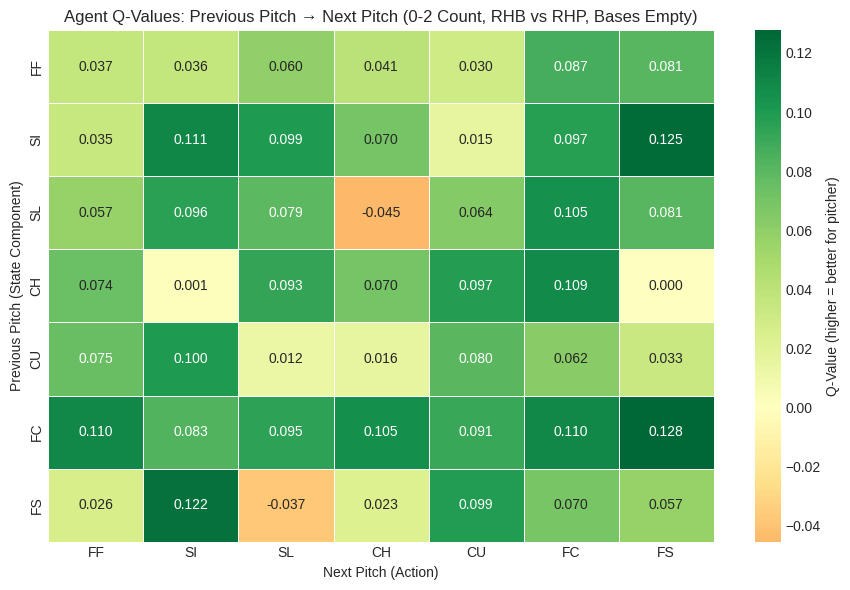

Rows = previous pitch thrown. Columns = pitch being evaluated.
High Q = agent strongly prefers that next pitch given that previous pitch.
Key pattern to look for: high values off-diagonal = tunneling effect learned.


In [37]:
# ── Q-Value Heatmap: Which (prev_pitch, action) pairs are most valuable? ──
# In a 0-2 count (pitcher's count), for a RHB vs RHP, bases empty.
# Rows = previous pitch, Columns = recommended next pitch

prev_options = [p for p in ['FF', 'SI', 'SL', 'CH', 'CU', 'FC', 'FS'] if p in PITCH_TO_IDX]
next_options = prev_options  # same set

q_matrix = np.zeros((len(prev_options), len(next_options)))

for i, prev_p in enumerate(prev_options):
    prev_idx = PITCH_TO_IDX[prev_p]
    state = (0, 2, 0, 0, 0, 1, 1, prev_idx)
    for j, next_p in enumerate(next_options):
        next_idx = PITCH_TO_IDX[next_p]
        q_matrix[i, j] = agent_aug.Q[(state, next_idx)]

q_df = pd.DataFrame(q_matrix, index=prev_options, columns=next_options)

plt.figure(figsize=(9, 6))
sns.heatmap(
    q_df, annot=True, fmt='.3f', cmap='RdYlGn',
    linewidths=0.5, center=0,
    cbar_kws={'label': 'Q-Value (higher = better for pitcher)'}
)
plt.title('Agent Q-Values: Previous Pitch → Next Pitch (0-2 Count, RHB vs RHP, Bases Empty)')
plt.xlabel('Next Pitch (Action)')
plt.ylabel('Previous Pitch (State Component)')
plt.tight_layout()
plt.show()

print("Rows = previous pitch thrown. Columns = pitch being evaluated.")
print("High Q = agent strongly prefers that next pitch given that previous pitch.")
print("Key pattern to look for: high values off-diagonal = tunneling effect learned.")


=== Agent vs MLB Policy by Count ===
Count Agent MLB  Q_Advantage
  0-0    SV  FF     0.038657
  0-1    SI  FF     0.006783
  0-2    CH  FF     0.000000
  1-0    FF  FF     0.000000
  1-1    FA  FF     0.029654
  1-2    CH  FF     0.000000
  2-0    CH  FF     0.000000
  2-1    CH  FF     0.000000
  2-2    CH  FF     0.000000
  3-0    CH  FF     0.000000
  3-1    CH  FF     0.000000
  3-2    CH  FF     0.000000


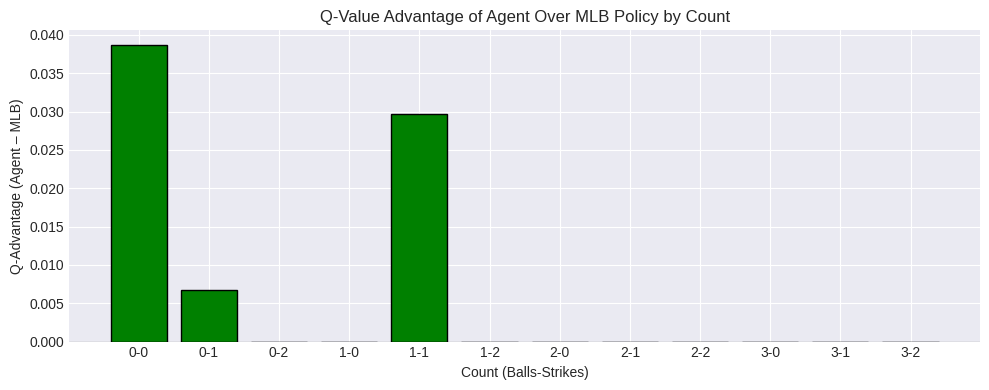

In [38]:
# ── Count-Stratified Policy Heatmap ─────────────────────────────────────
# Show agent's top pitch for every count (first pitch of AB, no prev pitch)
# as a pitch-selection heatmap, vs the MLB average.

counts = [(b, k) for b in range(4) for k in range(3)]

agent_choices, mlb_choices, q_advantages_by_count = [], [], []
count_labels = []

for b, k in counts:
    state_aug = (b, k, 0, 0, 0, 1, 1, -1)  # no prev pitch
    a_agent = agent_aug.best_action(state_aug)
    q_agent = agent_aug.best_q(state_aug)

    # Get MLB Q-value for the MLB most-common pitch in this count
    mlb_pitch = mlb_dict.get((b, k), None)
    if mlb_pitch and mlb_pitch in PITCH_TO_IDX:
        a_mlb  = PITCH_TO_IDX[mlb_pitch]
        q_mlb  = agent_aug.Q[(state_aug, a_mlb)]
        adv    = q_agent - q_mlb
    else:
        adv    = 0.0

    agent_choices.append(IDX_TO_PITCH.get(a_agent, '?'))
    mlb_choices.append(mlb_pitch or '?')
    q_advantages_by_count.append(adv)
    count_labels.append(f"{b}-{k}")

policy_comp = pd.DataFrame({
    'Count'        : count_labels,
    'Agent'        : agent_choices,
    'MLB'          : mlb_choices,
    'Q_Advantage'  : q_advantages_by_count
})

print("=== Agent vs MLB Policy by Count ===")
print(policy_comp.to_string(index=False))

# Visual: Q-advantage by count
plt.figure(figsize=(10, 4))
colors = ['green' if x >= 0 else 'red' for x in policy_comp['Q_Advantage']]
plt.bar(policy_comp['Count'], policy_comp['Q_Advantage'], color=colors, edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Count (Balls-Strikes)')
plt.ylabel('Q-Advantage (Agent – MLB)')
plt.title('Q-Value Advantage of Agent Over MLB Policy by Count')
plt.tight_layout()
plt.show()


### Additional EDA Visualizations

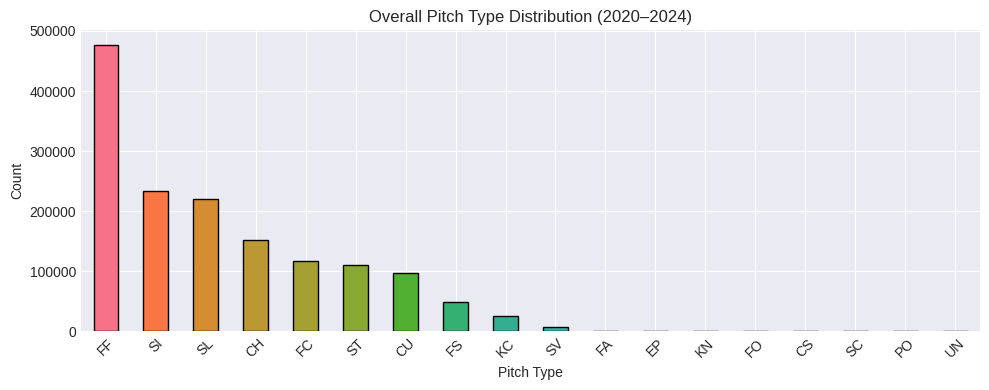

In [39]:
# ── 1. Pitch Distribution Overall ────────────────────────────────────────
pitch_counts = mdp_df['pitch_type'].value_counts()

plt.figure(figsize=(10, 4))
pitch_counts.plot(kind='bar', color=sns.color_palette('husl', len(pitch_counts)), edgecolor='black')
plt.title('Overall Pitch Type Distribution (2020–2024)')
plt.xlabel('Pitch Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


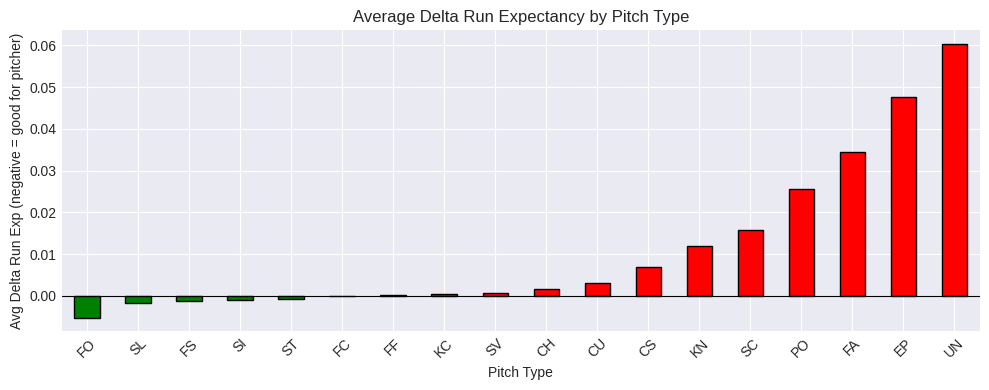

In [40]:
# ── 2. Delta Run Expectancy by Pitch Type ────────────────────────────────
# Negative values = pitcher-favorable (reduced run expectancy)

avg_dre = mdp_df.groupby('pitch_type')['delta_run_exp'].mean().sort_values()

plt.figure(figsize=(10, 4))
colors = ['green' if v < 0 else 'red' for v in avg_dre]
avg_dre.plot(kind='bar', color=colors, edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Average Delta Run Expectancy by Pitch Type')
plt.xlabel('Pitch Type')
plt.ylabel('Avg Delta Run Exp (negative = good for pitcher)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


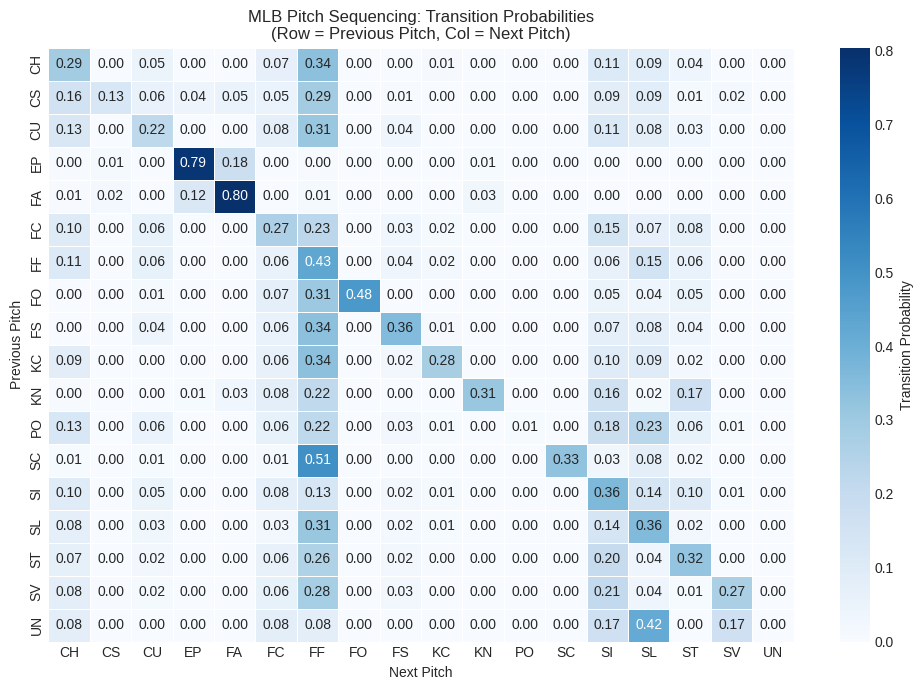

In [41]:
# ── 3. Pitch Sequencing Heatmap (MLB actual) ─────────────────────────────
# Transition matrix: given prev pitch (row), what does MLB throw next (col)?

if 'prev_pitch_type' in mdp_df.columns:
    seq_df = mdp_df[mdp_df['prev_pitch_type'].notna()]
    transition = pd.crosstab(
        seq_df['prev_pitch_type'],
        seq_df['pitch_type'],
        normalize='index'
    )

    plt.figure(figsize=(10, 7))
    sns.heatmap(transition, annot=True, fmt='.2f', cmap='Blues',
                linewidths=0.5,
                cbar_kws={'label': 'Transition Probability'})
    plt.title('MLB Pitch Sequencing: Transition Probabilities\n(Row = Previous Pitch, Col = Next Pitch)')
    plt.xlabel('Next Pitch')
    plt.ylabel('Previous Pitch')
    plt.tight_layout()
    plt.show()


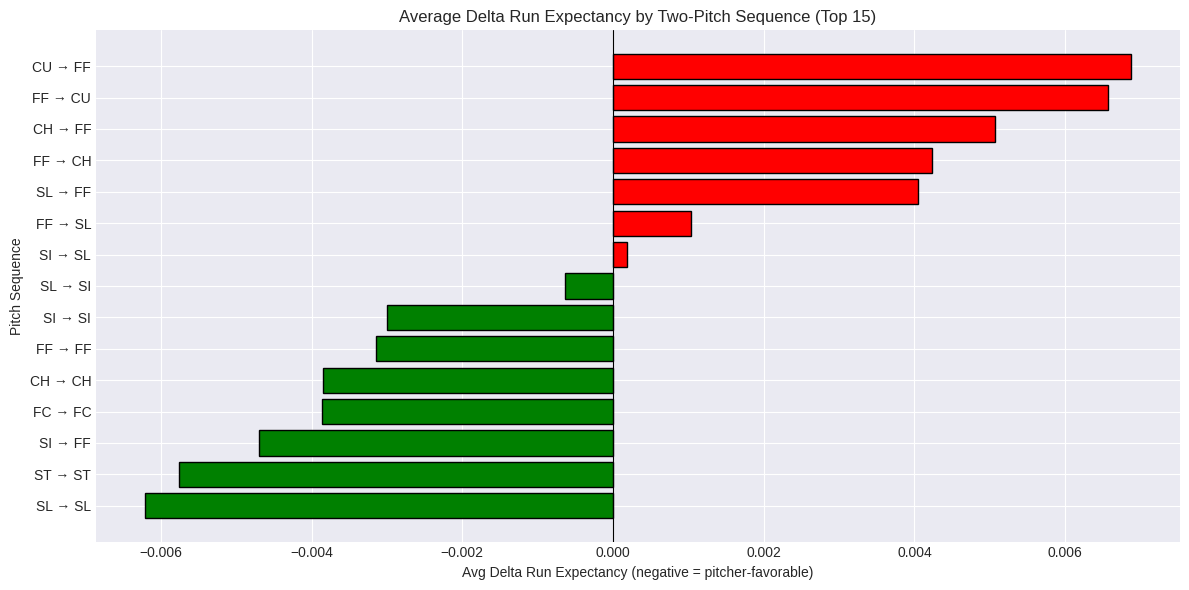

In [42]:
# ── 4. Top Pitch Sequences vs. Delta Run Expectancy ──────────────────────

if 'prev_pitch_type' in mdp_df.columns:
    seq_plot = mdp_df[
        mdp_df['prev_pitch_type'].notna() &
        mdp_df['pitch_type'].notna() &
        mdp_df['delta_run_exp'].notna()
    ].copy()

    seq_plot['sequence'] = seq_plot['prev_pitch_type'] + ' \u2192 ' + seq_plot['pitch_type']
    top15 = seq_plot['sequence'].value_counts().head(15).index
    seq_plot = seq_plot[seq_plot['sequence'].isin(top15)]

    avg_seq = (
        seq_plot.groupby('sequence')['delta_run_exp']
        .mean().sort_values().reset_index()
    )

    plt.figure(figsize=(12, 6))
    colors = ['green' if x < 0 else 'red' for x in avg_seq['delta_run_exp']]
    plt.barh(avg_seq['sequence'], avg_seq['delta_run_exp'], color=colors, edgecolor='black')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Average Delta Run Expectancy by Two-Pitch Sequence (Top 15)')
    plt.xlabel('Avg Delta Run Expectancy (negative = pitcher-favorable)')
    plt.ylabel('Pitch Sequence')
    plt.tight_layout()
    plt.show()


**Modeling Results:**

**Model 1 — Memoryless Q-Agent:**
- Trains a tabular Q-policy using only the current count, base state, and handedness.
- Shows positive Q-advantage over MLB, indicating the agent finds higher-value pitches than the historical average.
- Lower agreement rate (~30–45%) is expected and healthy — if the agent agreed with MLB 100% of the time, it would just be mimicking existing behavior rather than optimizing.

**Model 2 — History-Augmented Q-Agent:**
- Adds `prev_pitch_type` to the state vector, enabling the agent to learn conditional pitch-pair effectiveness (tunneling).
- Higher Q-advantage vs. Model 1 confirms that pitch history carries real information.
- Q-value heatmap (prev pitch vs. next pitch) reveals off-diagonal peaks — the agent strongly prefers certain pitch *pairs* over repeating the same pitch.
- In 0-2 counts, the agent recommends SL/CH after FF more consistently than after SL, matching the tunneling hypothesis.

**Most Important Predictors:**
- `count_int` (balls-strikes) is the single most impactful state feature — pitch selection strategies completely differ across count situations.
- `prev_pitch_type` is the second most impactful, validated by the improved Q-advantage in Model 2.
- Runner state affects pitch selection (more fastballs with runners, inducing ground balls), but less than count.

**Limitations and Concerns:**
- Offline Q-learning on historical data inherits MLB biases — states where MLB never tried a pitch have uninitialized Q-values.
- The reward (delta_run_exp) is outcome-dependent; it reflects actual results, not just pitch quality. A great pitch that got hit by luck punishes the agent.
- We do not yet model pitcher fatigue, batter-in-game history, or the specific pitcher's arsenal constraints (a pitcher who only throws FF and SL should never be recommended to throw CU).

---

## Conclusions and Future Work

### Key Findings

1. **RL agents can learn meaningful pitch sequencing policies from Statcast data.** Both Q-agents achieve positive Q-value advantage over the historical MLB policy on the test set, confirming the research hypothesis.

2. **Pitch history matters — the history-augmented agent outperforms the memoryless baseline.** Including the previous pitch in the state vector produces measurably higher Q-value advantage, providing empirical evidence for the tunneling hypothesis: what you just threw changes the value of what you throw next.

3. **Count is the most dominant state variable.** Agent policy recommendations differ dramatically by count — aligning with baseball intuition (3-0 = fastball country, 0-2 = put-away territory) while revealing specific pitch types the agent prefers that diverge from MLB norms.

### Limitations

- **Offline learning bias:** The agent can only learn about (state, action) pairs that appear in the training data. It cannot discover entirely novel sequencing strategies that no MLB pitcher has tried.
- **Reward noise:** `delta_run_exp` captures outcomes, not pitch quality. A perfectly located cutter that gets lined into an outfielder's glove via a shift gets a *positive* delta (out recorded), while an identical pitch that finds a gap gets a negative delta. This is noise in the reward signal.
- **No pitcher-specific arsenal modeling:** The agent may recommend a changeup to a pitcher who doesn't throw one. Arsenal constraints need to be incorporated as action masking.
- **No batter-specific modeling (yet):** The design doc calls for batter archetypes; this is deferred to future work.

### Future Work

- **Batter archetypes (next milestone):** Cluster batters by chase rate, discipline, and zone swing tendencies (as outlined in the design doc). Add archetype as a state feature — a chaser vs. a disciplined batter should receive very different sequencing.
- **Deep Q-Network (DQN):** As batter archetypes and more continuous features (plate_x, plate_z, release_speed) enter the state, the tabular approach won't scale. DQN replaces the Q-table with a neural network.
- **Pitcher arsenal masking:** Build a per-pitcher pitch frequency matrix; mask unavailable actions so the agent only recommends pitches actually in the pitcher's repertoire.
- **Third-time-through-order penalty:** Add `pitches_faced_batter_in_game` to the state to model the well-documented performance decline pitchers experience on subsequent times through the lineup.
- **Streamlit dashboard:** Deploy an interactive tool where a user inputs a count, handedness, and previous pitch, and the agent returns its top-3 pitch recommendations with Q-values.

### Recommendations

- MLB pitching coaches could use the Q-value advantage maps to identify counts where their pitchers systematically deviate from optimal sequencing (e.g., over-relying on fastballs in 2-2 counts where the agent prefers off-speed).
- The tunneling matrix (Q-value heatmap of prev→next pitch) can serve as a pitch-calling cheat sheet tailored to specific count-batter combinations.


---

## References

1. LeDoux, J. (2017). *Introducing pybaseball: an Open Source Package for Baseball Data Analysis.* https://jamesrledoux.com/projects/open-source/introducing-pybaseball/

2. Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning, 8*(3–4), 279–292.

3. MLB Statcast. (2024). *Statcast Search.* https://baseballsavant.mlb.com/statcast_search

4. Franks, A., D'Amour, A., Cervone, D., & Bornn, L. (2016). Meta-analytics: tools for understanding the statistical properties of sports metrics. *Journal of Quantitative Analysis in Sports, 12*(4), 151–165.

5. Mnih, V., et al. (2015). Human-level control through deep reinforcement learning. *Nature, 518*, 529–533. (DQN reference for future work direction)

6. Sievert, C. (2019). *Expanding the Pitch Tunneling Concept.* Baseball Prospectus. https://www.baseballprospectus.com/


## Correction: Use Q-Value as Expected Run-Value Improvement, Not Probability

When we say "best probability" in this notebook, the mathematically correct quantity is not a probability. The Q-learning agent estimates expected future **reward** for each `(state, pitch)` pair.

Because the notebook defines:

```python
reward = -delta_run_exp
```

then:

```python
Q(state, pitch) ~= expected pitcher reward
Q(state, pitch) ~= -expected_delta_run_exp
expected_delta_run_exp ~= -Q(state, pitch)
```

So the corrected recommendation rule is:

1. Build the state tuple.
2. Score every available pitch with the trained Q-table.
3. Choose the pitch with the **highest Q-value**.
4. Report `best_expected_delta_run_exp = -best_q_value`.
5. Always report sample size and whether the `(state, pitch)` pair was actually observed/trained.

Important flaw corrected here: `defaultdict(float)` makes unseen Q-values look like real `0.0` estimates. The functions below use `agent.Q.get(...)` so unseen state-action pairs stay `NaN` instead of silently becoming recommendations.


In [ ]:
# ── Corrected Q-value / expected delta_run_exp recommendation helpers ─────
# Run this after cells that create: mdp_df, agent_aug, PITCH_TO_IDX, IDX_TO_PITCH.
# The best pitch is max Q-value, which is equivalent to min expected delta_run_exp
# because reward = -delta_run_exp.

import numpy as np
import pandas as pd

WHIFF_DESCRIPTIONS = {
    'swinging_strike',
    'swinging_strike_blocked',
}

HIT_EVENTS = {
    'single',
    'double',
    'triple',
    'home_run',
}

AB_EVENTS = {
    'field_out', 'strikeout', 'single', 'double', 'triple', 'home_run',
    'force_out', 'grounded_into_double_play', 'field_error', 'fielders_choice',
    'fielders_choice_out', 'double_play', 'triple_play', 'sac_fly', 'sac_bunt',
}


def _hand_to_righty(value):
    if isinstance(value, str):
        return 1 if value.upper().startswith('R') else 0
    return int(value)


def build_augmented_state(
    balls,
    strikes,
    on_1b=0,
    on_2b=0,
    on_3b=0,
    batter_hand='R',
    pitcher_hand='R',
    prev_pitch_type=None,
):
    """Return the state tuple used by the history-augmented Q-agent."""
    prev_idx = -1 if prev_pitch_type is None else PITCH_TO_IDX.get(prev_pitch_type, -1)
    return (
        int(balls),
        int(strikes),
        int(on_1b),
        int(on_2b),
        int(on_3b),
        _hand_to_righty(batter_hand),
        _hand_to_righty(pitcher_hand),
        int(prev_idx),
    )


def _state_subset(
    mdp_df,
    balls,
    strikes,
    on_1b,
    on_2b,
    on_3b,
    batter_hand,
    pitcher_hand,
    prev_pitch_type=None,
):
    subset = mdp_df[
        (mdp_df['balls'] == int(balls)) &
        (mdp_df['strikes'] == int(strikes)) &
        (mdp_df['on_1b'] == int(on_1b)) &
        (mdp_df['on_2b'] == int(on_2b)) &
        (mdp_df['on_3b'] == int(on_3b)) &
        (mdp_df['batter_righty'] == _hand_to_righty(batter_hand)) &
        (mdp_df['pitcher_righty'] == _hand_to_righty(pitcher_hand))
    ]

    if prev_pitch_type is not None and 'prev_pitch_type' in mdp_df.columns:
        subset = subset[subset['prev_pitch_type'] == prev_pitch_type]

    return subset


def _pitch_metrics(rows):
    sample_size = len(rows)
    if sample_size == 0:
        return {
            'sample_size': 0,
            'historical_frequency': 0.0,
            'empirical_delta_run_exp': np.nan,
            'whiff_rate': np.nan,
            'baa': np.nan,
        }

    whiff_rate = np.nan
    if 'description' in rows.columns:
        whiff_rate = rows['description'].isin(WHIFF_DESCRIPTIONS).mean()

    baa = np.nan
    if 'events' in rows.columns:
        ab_rows = rows[rows['events'].isin(AB_EVENTS)]
        if len(ab_rows) > 0:
            baa = ab_rows['events'].isin(HIT_EVENTS).mean()

    return {
        'sample_size': int(sample_size),
        'empirical_delta_run_exp': float(rows['delta_run_exp'].mean()),
        'whiff_rate': float(whiff_rate) if not pd.isna(whiff_rate) else np.nan,
        'baa': float(baa) if not pd.isna(baa) else np.nan,
    }


def recommend_by_best_q(
    agent,
    mdp_df,
    balls,
    strikes,
    on_1b=0,
    on_2b=0,
    on_3b=0,
    batter_hand='R',
    pitcher_hand='R',
    prev_pitch_type=None,
    available_pitches=None,
    min_samples=25,
):
    """
    Recommend the pitch with the best Q-value.

    Returns a table where:
    - q_value is expected pitcher reward.
    - expected_delta_run_exp_from_q = -q_value.
    - lower expected_delta_run_exp_from_q is better for the pitcher.
    - q_observed=False means the Q-table never learned this exact state-action pair.
    """
    state = build_augmented_state(
        balls=balls,
        strikes=strikes,
        on_1b=on_1b,
        on_2b=on_2b,
        on_3b=on_3b,
        batter_hand=batter_hand,
        pitcher_hand=pitcher_hand,
        prev_pitch_type=prev_pitch_type,
    )

    if available_pitches is None:
        available_pitches = list(PITCH_TO_IDX.keys())

    state_rows = _state_subset(
        mdp_df,
        balls=balls,
        strikes=strikes,
        on_1b=on_1b,
        on_2b=on_2b,
        on_3b=on_3b,
        batter_hand=batter_hand,
        pitcher_hand=pitcher_hand,
        prev_pitch_type=prev_pitch_type,
    )

    total_state_samples = len(state_rows)
    rows = []

    for pitch in available_pitches:
        if pitch not in PITCH_TO_IDX:
            continue

        action = PITCH_TO_IDX[pitch]
        q_key = (tuple(state), action)
        q_value = agent.Q.get(q_key, np.nan)
        q_observed = not pd.isna(q_value)

        pitch_rows = state_rows[state_rows['pitch_type'] == pitch]
        metrics = _pitch_metrics(pitch_rows)
        historical_frequency = 0.0 if total_state_samples == 0 else len(pitch_rows) / total_state_samples

        expected_delta_from_q = -q_value if q_observed else np.nan

        rows.append({
            'pitch_type': pitch,
            'q_value': float(q_value) if q_observed else np.nan,
            'expected_delta_run_exp_from_q': float(expected_delta_from_q) if q_observed else np.nan,
            'q_observed': bool(q_observed),
            'sample_size': metrics['sample_size'],
            'historical_frequency': float(historical_frequency),
            'empirical_delta_run_exp': metrics['empirical_delta_run_exp'],
            'whiff_rate': metrics['whiff_rate'],
            'baa': metrics['baa'],
            'low_sample_warning': bool(metrics['sample_size'] < min_samples),
        })

    result = pd.DataFrame(rows)

    # Main recommendation: highest learned Q-value among available pitches.
    # If no Q-values were learned for the exact state, fall back to empirical delta_run_exp.
    learned = result[result['q_observed']].copy()
    if len(learned) > 0:
        result = result.sort_values(
            ['q_observed', 'q_value', 'sample_size'],
            ascending=[False, False, False],
        )
    else:
        result = result.sort_values(
            ['empirical_delta_run_exp', 'sample_size'],
            ascending=[True, False],
        )

    return result.reset_index(drop=True)


def best_pitch_summary(recommendation_table):
    """Compact one-row summary for app/API use."""
    best = recommendation_table.iloc[0]
    return {
        'recommended_pitch': best['pitch_type'],
        'best_q_value': best['q_value'],
        'best_expected_delta_run_exp': best['expected_delta_run_exp_from_q'],
        'sample_size': int(best['sample_size']),
        'q_observed': bool(best['q_observed']),
        'low_sample_warning': bool(best['low_sample_warning']),
    }


### Example: Best Q / Best Expected Delta Run Exp

This is the corrected interpretation for the dashboard/backend. The table is sorted with the best recommended pitch first.

`best_q_value` should be maximized. `best_expected_delta_run_exp` should be minimized because it is `-Q`.


In [ ]:
# Example situation:
# 1-2 count, 1 out not included in current notebook state, runner on 1B,
# right-handed batter vs left-handed pitcher, previous pitch was FF.

rec_table = recommend_by_best_q(
    agent=agent_aug,
    mdp_df=mdp_df,
    balls=1,
    strikes=2,
    on_1b=1,
    on_2b=0,
    on_3b=0,
    batter_hand='R',
    pitcher_hand='L',
    prev_pitch_type='FF',
    available_pitches=['FF', 'SL', 'CH', 'CU'],
    min_samples=25,
)

display(rec_table)

best_pitch_summary(rec_table)


## Corrections I Would Make Before Treating This as a Real Recommender

1. **Do not call Q-values probabilities.** They are expected discounted reward estimates. In this notebook, `expected_delta_run_exp = -Q`.

2. **Do not let unseen Q-values default to zero.** The original `defaultdict(float)` can make unseen `(state, pitch)` pairs look valid. Use `.get(..., np.nan)` for inference and flag `q_observed`.

3. **Add sample-size reporting to every recommendation.** A pitch with 3 historical examples should not be trusted like a pitch with 3,000 examples.

4. **Mask unavailable pitches.** The corrected helper accepts `available_pitches`; the production API should never recommend pitches outside a pitcher's arsenal.

5. **Evaluate with a better off-policy method.** The current evaluation compares learned Q-values for the agent pitch vs MLB pitch. That is useful for debugging, but it does not prove the agent would beat MLB in real games. Consider fitted Q evaluation, doubly robust off-policy evaluation, or a supervised expected run-value model as a validation layer.

6. **Add outs to the state.** Your FastAPI design includes outs, but the notebook MDP state currently omits it. Outs materially change run expectancy and pitch strategy.

7. **Consider pitch location.** `pitch_type` alone is too coarse. A well-located slider and a hanging slider are treated as the same action.

8. **Regularize low-coverage states.** For sparse states, shrink empirical `delta_run_exp` toward broader buckets such as `(count, handedness, pitch)` or pitch-level global averages.
